In [1]:
# ==============================================================================
# CELDA 0: RUTAS DEL REPOSITORIO
# Este cuaderno leia sus datos desde Google Drive. Ahora los lee del propio
# repositorio, de modo que corre en cualquier clon sin configuracion previa.
# La raiz se resuelve buscando hacia arriba: funciona igual si el cuaderno se
# ejecuta desde su carpeta o desde la raiz del proyecto.
# ==============================================================================
from pathlib import Path

def _raiz_del_repositorio() -> Path:
    actual = Path.cwd().resolve()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / 'pyproject.toml').exists() and (carpeta / 'quanta').is_dir():
            return carpeta
    raise RuntimeError(
        'No se encontro la raiz del repositorio. Ejecute el cuaderno desde '
        'dentro del proyecto indice-sned.'
    )

RAIZ            = _raiz_del_repositorio()
RUTA_RAW        = (RAIZ / 'data' / 'raw').as_posix() + '/'
RUTA_PROCESADOS = (RAIZ / 'data' / 'processed').as_posix() + '/'
RUTA_REGISTRO   = (RAIZ / 'models' / 'registry').as_posix() + '/'
RUTA_METADATOS  = (RAIZ / 'models' / 'metadata').as_posix() + '/'

print('Raiz del repositorio:', RAIZ)


Raiz del repositorio: C:\Users\guill\Escritorio\indice-sned


In [2]:
# ==============================================================================
# CELDA 1: LIBRERÍAS Y ENTORNO
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("Entorno listo. Pandas:", pd.__version__)

Entorno listo. Pandas: 2.2.3


In [3]:
# ==============================================================================
# CELDA 2: INGESTA SEGURA DE ARCHIVOS SNED (DATAFRAMES BRUTOS)
# ==============================================================================
RUTA_BASE_SNED = RUTA_RAW + 'sned/'

archivos_sned = {
    'sned_2016_17': 'SNED_2016_2017.csv',
    'sned_2018_19': 'SNED_2018_2019.csv',
    'sned_2020_21': 'SNED_2020_2021.csv',
    'sned_2022_23': 'SNED_2022_2023.csv',
    'sned_2024_25': 'SNED_2024_2025.csv',
    # Ciclo obtenido por Ley de Transparencia. Queda FUERA de la ventana de
    # entrenamiento a proposito: es el conjunto de validacion temporal, el
    # unico ciclo que el modelo no vio nunca.
    'sned_2026_27': 'SNED_2026_2027.csv',
}

# Diccionario que contendrá los DataFrames brutos
sned_brutos = {}

for clave, nombre_archivo in archivos_sned.items():
    ruta_completa = RUTA_BASE_SNED + nombre_archivo
    # Los archivos no comparten codificacion: los publicados en el portal vienen
    # en UTF-8 con marca de orden de bytes, y los entregados por Ley de
    # Transparencia en latin-1. Se prueban ambas y se declara cual funciono, en
    # vez de fijar una y perder el archivo en silencio.
    for codificacion in ('utf-8-sig', 'latin-1'):
        try:
            sned_brutos[clave] = pd.read_csv(ruta_completa, encoding=codificacion, sep=';')
            print(f"OK      | {clave:<13} | {sned_brutos[clave].shape[0]:>6} filas x "
                  f"{sned_brutos[clave].shape[1]:>3} columnas | {codificacion}")
            break
        except FileNotFoundError:
            print(f"FALTA   | {clave:<13} | No se encontró: {nombre_archivo}")
            break
        except UnicodeDecodeError:
            continue
        except Exception as e:
            print(f"ERROR   | {clave:<13} | {type(e).__name__}: {e}")
            break
    else:
        print(f"ERROR   | {clave:<13} | No se pudo decodificar con ninguna codificacion probada")

print(f"\nTotal de DataFrames cargados en memoria: {len(sned_brutos)} de {len(archivos_sned)}")

# ==============================================================================
# INSPECCIÓN RÁPIDA DE ESQUEMAS (para detectar columnas que cambian entre ciclos)
# ==============================================================================
print("\n--- Columnas por ciclo ---")
for clave, d in sned_brutos.items():
    print(f"\n{clave}: {d.columns.tolist()}")

OK      | sned_2016_17  |  11163 filas x  25 columnas
OK      | sned_2018_19  |  11025 filas x  25 columnas
OK      | sned_2020_21  |  10780 filas x  25 columnas
OK      | sned_2022_23  |  10701 filas x  25 columnas
OK      | sned_2024_25  |  10722 filas x  25 columnas
ERROR   | sned_2026_27  | UnicodeDecodeError: 'utf-8' codec can't decode byte 0xd1 in position 3375: invalid continuation byte

Total de DataFrames cargados en memoria: 5 de 6

--- Columnas por ciclo ---

sned_2016_17: ['RBD', 'DV_RBD', 'NOM_RBD', 'RBD_A1', 'RBD_A2', 'COD_DEPE', 'COD_DEPE2', 'COD_REG_RBD', 'COD_PRO_RBD', 'COD_COM_RBD', 'NOM_COM_RBD', 'COD_DEPROV_RBD', 'NOM_DEPROV_RBD', 'RURAL_RBD', 'EFECTIVR', 'SUPERAR', 'INICIAR', 'MEJORAR', 'INTEGRAR', 'IGUALDR', 'CLUSTER', 'INDICER', 'SEL2016_25', 'SEL2016_35', 'SEL']

sned_2018_19: ['RBD', 'DV_RBD', 'NOM_RBD', 'RBD_A1', 'RBD_A2', 'COD_DEPE', 'COD_DEPE2', 'COD_REG_RBD', 'COD_PRO_RBD', 'COD_COM_RBD', 'NOM_COM_RBD', 'COD_DEPROV_RBD', 'NOM_DEPROV_RBD', 'RURAL_RBD', 'EFEC

In [4]:
# ==============================================================================
# CELDA 3: LIMPIEZA, ESTANDARIZACIÓN Y HARMONIZACIÓN SNED
# ==============================================================================
COLS_DROP = ['NOM_COM_RBD', 'COD_DEPROV_RBD', 'NOM_DEPROV_RBD', 'DV_RBD']
FACTORES = ['EFECTIVR', 'SUPERAR', 'INICIAR', 'MEJORAR', 'INTEGRAR', 'IGUALDR', 'INDICER']
COLS_CATEGORICAS = ['COD_DEPE', 'COD_DEPE2', 'COD_REG_RBD', 'COD_PRO_RBD', 'COD_COM_RBD']

sned_limpios = {}

for clave, df_bruto in sned_brutos.items():
    d = df_bruto.copy()
    etiqueta_premio = clave.replace('sned_', '').replace('_', '-')

    d = d.drop(columns=[c for c in COLS_DROP if c in d.columns])

    for col in FACTORES:
        original_nulos = int(d[col].isnull().sum())
        d[col] = pd.to_numeric(d[col].astype(str).str.replace(',', '.'), errors='coerce')
        coercionados = int(d[col].isnull().sum()) - original_nulos
        if coercionados > 0:
            print(f"AVISO   | {clave:<13} | {col}: {coercionados} valores no parseables -> NaN")
        d[col] = d[col].clip(lower=0).astype('float32')

    renombres_sel = {c: 'SEL_' + c.split('_')[1] for c in d.columns
                     if c.startswith('SEL') and '_' in c}
    d = d.rename(columns=renombres_sel)

    d['RBD'] = pd.to_numeric(d['RBD'], errors='coerce').astype('Int64')
    if d['RBD'].isnull().any():
        print(f"AVISO   | {clave:<13} | {int(d['RBD'].isnull().sum())} filas sin RBD válido eliminadas")
        d = d.dropna(subset=['RBD'])
    d['RBD'] = d['RBD'].astype(str)

    for col in ['RBD_A1', 'RBD_A2']:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors='coerce').astype('Int64').astype('string')

    # --- Normalización de RURAL_RBD: deriva de codificación detectada empíricamente ---
    # 2016-17 y 2018-19 usan esquema oficial {1=Urbana, 2=Rural}
    # 2020-21 en adelante usan {0=Urbana, 1=Rural}
    # Estandarizamos TODO a booleano explícito: True = Rural
    rural_raw = pd.to_numeric(d['RURAL_RBD'], errors='coerce')
    if etiqueta_premio in ['2016-17', '2018-19']:
        d['ES_RURAL'] = (rural_raw == 2)
    else:
        d['ES_RURAL'] = (rural_raw == 1)
    d = d.drop(columns=['RURAL_RBD'])

    d['NOM_RBD'] = d['NOM_RBD'].astype(str).str.strip()
    d['CLUSTER'] = d['CLUSTER'].astype(str).str.strip()
    for col in COLS_CATEGORICAS:
        d[col] = pd.to_numeric(d[col], errors='coerce').astype('Int64').astype('string')
    for col in ['SEL_25', 'SEL_35', 'SEL']:
        d[col] = pd.to_numeric(d[col], errors='coerce').astype('Int8')

    # Diagnóstico del "intruso" COD_DEPE2=3 (particulares pagados, fuera del universo subvencionado)
    n_intrusos = int((d['COD_DEPE2'] == '3').sum())
    if n_intrusos > 0:
        print(f"AVISO   | {clave:<13} | {n_intrusos} establecimientos con COD_DEPE2='3' (particular pagado, no subvencionado)")

    d['BIENIO_PREMIO'] = etiqueta_premio

    sned_limpios[clave] = d
    print(f"OK      | {clave:<13} | {d.shape[0]:>6} filas x {d.shape[1]:>2} columnas | BIENIO_PREMIO='{etiqueta_premio}'")

print(f"\nTotal de DataFrames limpios: {len(sned_limpios)} de {len(sned_brutos)}")

# Auditoría inmediata de la normalización
print("\n--- Verificación ES_RURAL post-normalización (debe ser ~32% en los 5 ciclos) ---")
for clave, d in sned_limpios.items():
    pct_rural = d['ES_RURAL'].mean() * 100
    print(f"{clave:<13} | Rural: {int(d['ES_RURAL'].sum())} ({pct_rural:.1f}%)")

AVISO   | sned_2016_17  | EFECTIVR: 1879 valores no parseables -> NaN
AVISO   | sned_2016_17  | SUPERAR: 1879 valores no parseables -> NaN
OK      | sned_2016_17  |  11163 filas x 22 columnas | BIENIO_PREMIO='2016-17'
AVISO   | sned_2018_19  | EFECTIVR: 1913 valores no parseables -> NaN
AVISO   | sned_2018_19  | SUPERAR: 1913 valores no parseables -> NaN
AVISO   | sned_2018_19  | 91 establecimientos con COD_DEPE2='3' (particular pagado, no subvencionado)
OK      | sned_2018_19  |  11025 filas x 22 columnas | BIENIO_PREMIO='2018-19'
AVISO   | sned_2020_21  | EFECTIVR: 1919 valores no parseables -> NaN
AVISO   | sned_2020_21  | SUPERAR: 1919 valores no parseables -> NaN
AVISO   | sned_2020_21  | 2 establecimientos con COD_DEPE2='3' (particular pagado, no subvencionado)
OK      | sned_2020_21  |  10780 filas x 22 columnas | BIENIO_PREMIO='2020-21'
AVISO   | sned_2022_23  | EFECTIVR: 1943 valores no parseables -> NaN
AVISO   | sned_2022_23  | SUPERAR: 1943 valores no parseables -> NaN
OK  

In [5]:
# ==============================================================================
# DIAGNÓSTICO: ¿QUIÉNES SON LOS 91 "PARTICULARES PAGADOS" DE 2018-19?
# ==============================================================================
intrusos = sned_limpios['sned_2018_19'][sned_limpios['sned_2018_19']['COD_DEPE2'] == '3']
print(f"Total: {len(intrusos)}")
print(intrusos[['RBD', 'NOM_RBD', 'COD_REG_RBD', 'SEL']].head(15).to_string(index=False))
print(f"\n¿Fueron seleccionados alguna vez?: {intrusos['SEL'].value_counts().to_dict()}")

Total: 91
  RBD                            NOM_RBD COD_REG_RBD  SEL
  139           JARDIN INFANTIL CONEJITO           1    3
  580            COLEGIO GERONIMO RENDIC           4    3
  582               COLEGIO ANDRES BELLO           4    3
  590        COLEGIO PARTICULAR SAN JOSE           4    3
 1226           COLEGIO MARIA MONTESSORI           5    3
 1391         LICEO COMERCIAL PARTICULAR           5    3
 1823       ESCUELA N° 340 LORD COCHRANE           5    3
 8768          LICEO JOSE MIGUEL CARRERA          13    3
 8846      COLEGIO INMACULADA CONCEPCION          13    3
 9826  ESCUELA PARTICULAR LOS CAPULLITOS          13    3
 9941         COLEGIO PARTICULAR DE ASIS          13    3
10611           COLEGIO AMERICAN ACADEMY          13    3
11103                COLEGIO LOS CARRERA           4    3
11107 COLEGIO PART.SANTA TERESA DE JESUS           4    3
11241               JOSEPH LISTER SCHOOL           5    3

¿Fueron seleccionados alguna vez?: {3: 91}


In [6]:
# ==============================================================================
# CELDA 4: AUDITORÍA DE TIPOS, LLAVES, RANGOS Y CODIFICACIONES
# ==============================================================================
print("--- Auditoría por ciclo de premio ---")
for clave, d in sned_limpios.items():
    dup_rbd = int(d['RBD'].duplicated().sum())
    nan_factores = int(d[FACTORES].isnull().sum().sum())
    con_anexo = int(d['RBD_A1'].notna().sum()) if 'RBD_A1' in d.columns else 0
    print(f"{clave:<13} | RBD duplicados: {dup_rbd} | NaN en factores: {nan_factores:>5} | "
          f"INDICER [{d['INDICER'].min():.1f}, {d['INDICER'].max():.1f}] | matrices con anexo: {con_anexo}")

# Verificación de ES_RURAL (ya normalizada en la Celda 3; debe rondar ~30-32% en los 5 ciclos)
print("\n--- ES_RURAL por ciclo (normalizada; True = Rural) ---")
for clave, d in sned_limpios.items():
    print(f"{clave:<13} | {d['ES_RURAL'].value_counts(dropna=False).to_dict()}")

print("\n--- SEL por ciclo (esquema oficial: 1=sel. 25%, 2=sel. 35%, 3=no sel.) ---")
for clave, d in sned_limpios.items():
    print(f"{clave:<13} | {d['SEL'].value_counts(dropna=False).to_dict()}")

print("\n--- COD_DEPE2 por ciclo (1=Municipal, 2=P.Subv, 3=¡intruso!, 4=Adm.Deleg, 5=SLE) ---")
for clave, d in sned_limpios.items():
    print(f"{clave:<13} | {d['COD_DEPE2'].value_counts(dropna=False).to_dict()}")

print("\n--- df.info() de muestra: sned_2024_25 ---")
print(sned_limpios['sned_2024_25'].info())

--- Auditoría por ciclo de premio ---
sned_2016_17  | RBD duplicados: 0 | NaN en factores:  3758 | INDICER [35.5, 98.8] | matrices con anexo: 30
sned_2018_19  | RBD duplicados: 0 | NaN en factores:  3826 | INDICER [29.3, 98.8] | matrices con anexo: 28
sned_2020_21  | RBD duplicados: 0 | NaN en factores:  3838 | INDICER [5.0, 100.0] | matrices con anexo: 28
sned_2022_23  | RBD duplicados: 0 | NaN en factores:  3886 | INDICER [30.3, 100.0] | matrices con anexo: 14
sned_2024_25  | RBD duplicados: 0 | NaN en factores:  3936 | INDICER [36.4, 97.8] | matrices con anexo: 13

--- ES_RURAL por ciclo (normalizada; True = Rural) ---
sned_2016_17  | {False: 7552, True: 3611}
sned_2018_19  | {False: 7528, True: 3497}
sned_2020_21  | {False: 7396, True: 3384}
sned_2022_23  | {False: 7398, True: 3303}
sned_2024_25  | {False: 7438, True: 3284}

--- SEL por ciclo (esquema oficial: 1=sel. 25%, 2=sel. 35%, 3=no sel.) ---
sned_2016_17  | {3: 8309, 1: 2052, 2: 802}
sned_2018_19  | {3: 8178, 1: 2002, 2: 845

In [7]:
# ==============================================================================
# EXCLUSIÓN DE ESTABLECIMIENTOS PARTICULARES PAGADOS (fuera del universo SNED)
# ==============================================================================
establecimientos_excluidos = {}

for clave, d in sned_limpios.items():
    mascara_excluir = d['COD_DEPE2'] == '3'
    n_excluidos = int(mascara_excluir.sum())

    if n_excluidos > 0:
        establecimientos_excluidos[clave] = d.loc[mascara_excluir, ['RBD', 'NOM_RBD']].copy()
        sned_limpios[clave] = d.loc[~mascara_excluir].reset_index(drop=True)
        print(f"{clave:<13} | {n_excluidos:>3} establecimientos particulares pagados excluidos | quedan {len(sned_limpios[clave])} filas")
    else:
        print(f"{clave:<13} |   0 establecimientos particulares pagados excluidos | quedan {len(d)} filas")

# Consolidamos el registro de exclusión para la sección de metodología de la tesis
total_excluidos = sum(len(v) for v in establecimientos_excluidos.values())
print(f"\nTotal de registros excluidos en todo el pipeline: {total_excluidos}")
print("Justificación: COD_DEPE2='3' identifica establecimientos particulares pagados,")
print("sin subvención estatal, que estructuralmente no pueden ser seleccionados (SEL=3 en el 100% de los casos)")
print("y que el propio Esquema de Registro SNED reconoce como ajenos al universo subvencionado evaluado.")

sned_2016_17  |   0 establecimientos particulares pagados excluidos | quedan 11163 filas
sned_2018_19  |  91 establecimientos particulares pagados excluidos | quedan 10934 filas
sned_2020_21  |   2 establecimientos particulares pagados excluidos | quedan 10778 filas
sned_2022_23  |   0 establecimientos particulares pagados excluidos | quedan 10701 filas
sned_2024_25  |   0 establecimientos particulares pagados excluidos | quedan 10722 filas

Total de registros excluidos en todo el pipeline: 93
Justificación: COD_DEPE2='3' identifica establecimientos particulares pagados,
sin subvención estatal, que estructuralmente no pueden ser seleccionados (SEL=3 en el 100% de los casos)
y que el propio Esquema de Registro SNED reconoce como ajenos al universo subvencionado evaluado.


## Test de Congelamiento: correlación de EFECTIVR entre ciclos

In [8]:
# ==============================================================================
# CELDA 5: TEST DE CONGELAMIENTO — CORRELACIÓN DE EFECTIVR ENTRE CICLOS DE PREMIO
# ==============================================================================
from itertools import combinations

ciclos = list(sned_limpios.keys())
resultados = []

for c1, c2 in combinations(ciclos, 2):
    d1 = sned_limpios[c1][['RBD', 'EFECTIVR']].rename(columns={'EFECTIVR': 'EF_1'})
    d2 = sned_limpios[c2][['RBD', 'EFECTIVR']].rename(columns={'EFECTIVR': 'EF_2'})

    # Inner join: solo colegios presentes en ambos ciclos, con EFECTIVR no nulo en ambos
    cruce = pd.merge(d1, d2, on='RBD', how='inner', validate='one_to_one').dropna()

    if len(cruce) > 1:
        r = cruce['EF_1'].corr(cruce['EF_2'])
        # Diferencia absoluta promedio: si r~1 y diff~0, son prácticamente el mismo dato
        diff_abs_media = (cruce['EF_1'] - cruce['EF_2']).abs().mean()
        idénticos_exactos = int((cruce['EF_1'] == cruce['EF_2']).sum())
        pct_identicos = idénticos_exactos / len(cruce) * 100

        resultados.append({
            'ciclo_A': c1.replace('sned_', ''),
            'ciclo_B': c2.replace('sned_', ''),
            'n_colegios': len(cruce),
            'correlacion_r': round(r, 4),
            'diff_abs_media': round(diff_abs_media, 3),
            'pct_valores_identicos': round(pct_identicos, 1),
        })

df_congelamiento = pd.DataFrame(resultados).sort_values('correlacion_r', ascending=False)

print("--- Test de Congelamiento: EFECTIVR entre pares de ciclos SNED ---\n")
print(df_congelamiento.to_string(index=False))

print("\n--- Interpretación ---")
print("r > 0.98 y % idénticos alto  => ciclos que comparten la misma ventana SIMCE (congelamiento)")
print("r moderado, % idénticos bajo => ciclos con ventanas SIMCE genuinamente distintas")

--- Test de Congelamiento: EFECTIVR entre pares de ciclos SNED ---

ciclo_A ciclo_B  n_colegios  correlacion_r  diff_abs_media  pct_valores_identicos
2020_21 2022_23        8726         0.9750        1.240000                    0.0
2022_23 2024_25        8619         0.9706        0.561000                    0.0
2020_21 2024_25        8605         0.9476        1.634000                    0.0
2018_19 2022_23        8652         0.6948        8.144000                    0.0
2018_19 2020_21        8773         0.6917        8.139000                    0.0
2018_19 2024_25        8567         0.6782        8.328000                    0.0
2016_17 2018_19        8956         0.6241       12.929000                    0.0
2016_17 2020_21        8729         0.5893       18.940001                    0.0
2016_17 2022_23        8609         0.5855       18.974001                    0.0
2016_17 2024_25        8553         0.5711       19.153000                    0.0

--- Interpretación ---
r > 0.

**Conclusión — Test de Congelamiento (EFECTIVR entre ciclos SNED)**

Los resultados matizan la hipótesis de congelamiento total planteada en la Sección 4 del informe metodológico: **no hay reutilización literal del dato**, pero sí una fuerte dependencia estructural entre los tres ciclos más recientes.

Los pares (2020-21, 2022-23), (2022-23, 2024-25) y (2020-21, 2024-25) muestran correlaciones muy altas (r = 0,95–0,98), pero **0% de valores idénticos exactos** y diferencias absolutas promedio pequeñas pero no nulas (0,56–1,63 puntos). Esto indica que estos tres ciclos comparten en gran medida la misma información SIMCE de base, tal como documenta el Ministerio, pero el factor `EFECTIVR` no se copia tal cual entre ciclos: se **reescala cada vez** contra el mínimo y máximo nacional observado en ese proceso específico (fórmula oficial de ajuste 0-100), lo que introduce pequeñas variaciones numéricas aun cuando el puntaje SIMCE subyacente sea el mismo. En términos prácticos, estos tres ciclos deben tratarse como **altamente correlacionados pero no como triplicado exacto** de una sola observación — hay redundancia informativa real y sustancial, no independencia entre estos tres periodos de premio.

El panorama cambia con 2018-19: su correlación con los tres ciclos posteriores cae a un rango moderado (r = 0,68–0,69), y con 2016-17 desciende aún más (r = 0,57–0,62), con diferencias absolutas medias crecientes (hasta ~19 puntos). Esto sugiere que 2016-19 no comparte la misma ventana congelada que 2020-25, sino que responde a mediciones SIMCE propias y más antiguas — consistente con que la ventana pre-pandemia "congelada" (2017-2018-2019) recién se fija como tal a partir del ciclo 2020-21, mientras que 2016-17 y 2018-19 aún reflejan su propio ciclo natural de evaluación bienal.

**Implicancia para el diseño del modelo:** de los cinco ciclos disponibles, los tres más recientes (2020-21, 2022-23, 2024-25) no deben tratarse como tres observaciones estadísticamente independientes al construir conjuntos de entrenamiento y validación — hacerlo sobreestimaría el desempeño real de generalización del modelo. En cambio, 2016-17 y 2018-19 sí aportan variabilidad genuina y complementaria, y son los candidatos más valiosos para una partición de validación temporal robusta.

## Diagnóstico diferenciado de los NaN estructurales:

Diagnóstico diferenciado de los NaN de Efectividad/Superación — separar educación especial (sin factor aplicable, exclusión limpia) de los casos con valor imputado por grupo homogéneo (parvularia/adultos/cárceles — candidatos a exclusión también, porque su "desempeño" no es predecible desde SIMCE).

In [9]:
# ==============================================================================
# CELDA 6: DIAGNÓSTICO DIFERENCIADO — ¿QUÉ TIPO DE ESTABLECIMIENTO HAY DETRÁS
# DE LOS NaN Y DE LOS VALORES IMPUTADOS EN EFECTIVIDAD/SUPERACIÓN?
# ==============================================================================
import re

# Palabras clave que delatan tipo de establecimiento en el nombre
PATRONES = {
    'ESPECIAL':   r'\bESPECIAL\b|\bDIFERENCIAL\b',
    'PARVULARIO': r'\bPARVULAR\w*\b|\bJARDIN\b|\bJARDÍN\b',
    'ADULTOS':    r'\bADULTOS\b|\bC\.E\.I\.A\b|\bCEIA\b',
    'CARCEL':     r'\bC[AÁ]RCEL\b|\bPENAL\b|\bENCIERRO\b',
}

def clasificar_nombre(nombre):
    for etiqueta, patron in PATRONES.items():
        if re.search(patron, nombre, flags=re.IGNORECASE):
            return etiqueta
    return 'REGULAR (sin patrón detectado)'

resumen_diagnostico = []

for clave, d in sned_limpios.items():
    nan_mask = d['EFECTIVR'].isnull()
    n_nan = int(nan_mask.sum())

    clasificacion = d.loc[nan_mask, 'NOM_RBD'].apply(clasificar_nombre)
    conteo = clasificacion.value_counts()

    print(f"\n===== {clave} | {n_nan} establecimientos con EFECTIVR nulo =====")
    print(conteo.to_string())

    resumen_diagnostico.append({
        'ciclo': clave.replace('sned_', ''),
        'n_nan_total': n_nan,
        **{k: conteo.get(k, 0) for k in list(PATRONES.keys()) + ['REGULAR (sin patrón detectado)']}
    })

df_resumen_nan = pd.DataFrame(resumen_diagnostico)
print("\n--- Resumen consolidado por ciclo ---")
print(df_resumen_nan.to_string(index=False))

# Muestra de los "REGULAR" para inspeccionar si son error o un patrón de nombre no capturado
print("\n--- Muestra de NaN clasificados como 'REGULAR' (revisar manualmente) ---")
d_2425 = sned_limpios['sned_2024_25']
regulares = d_2425.loc[d_2425['EFECTIVR'].isnull() &
                        (d_2425['NOM_RBD'].apply(clasificar_nombre) == 'REGULAR (sin patrón detectado)')]
print(regulares[['RBD', 'NOM_RBD', 'COD_DEPE2']].head(15).to_string(index=False))


===== sned_2016_17 | 1879 establecimientos con EFECTIVR nulo =====
NOM_RBD
ESPECIAL                          1025
REGULAR (sin patrón detectado)     836
PARVULARIO                          18

===== sned_2018_19 | 1910 establecimientos con EFECTIVR nulo =====
NOM_RBD
ESPECIAL                          1081
REGULAR (sin patrón detectado)     816
PARVULARIO                          13

===== sned_2020_21 | 1919 establecimientos con EFECTIVR nulo =====
NOM_RBD
ESPECIAL                          1109
REGULAR (sin patrón detectado)     797
PARVULARIO                          13

===== sned_2022_23 | 1943 establecimientos con EFECTIVR nulo =====
NOM_RBD
ESPECIAL                          1125
REGULAR (sin patrón detectado)     804
PARVULARIO                          14

===== sned_2024_25 | 1968 establecimientos con EFECTIVR nulo =====
NOM_RBD
ESPECIAL                          1124
REGULAR (sin patrón detectado)     826
PARVULARIO                          18

--- Resumen consolidado por ciclo 

## Reclasificación ampliada y verificación de cierre

Consolidación del maestro SNED — unir los cinco ciclos en un solo DataFrame (aquí es puro concat, sin groupby, porque cada archivo ya es una fila por colegio).

In [10]:
# ==============================================================================
# CELDA 7: RECLASIFICACIÓN AMPLIADA DE LOS NaN "REGULAR (sin patrón detectado)"
# ==============================================================================
PATRONES_V2 = {
    'ESPECIAL': (
        r'\bESPECIAL\b|\bDIFERENCIAL\b|\bBRAILLE\b|\bS\.?\s?DOWN\b|\bPSICOPEDAG\w*\b|'
        r'\bCAPACITACI[OÓ]N LABORAL\b|\bLABORAL\b|\bTRATAMIEN\w*\s?INTEGRAL\b|'
        r'\bDESARR\w*\s?(PARA)?\s?NI[NÑ]OS\b|\bAUDICI[OÓ]N\b|\bLENGUAJE\b|\bHIPOACUSIC\w*\b|'
        r'\bCIEGOS?\b|\bSORDOS?\b|\bMULTID[EÉ]FICIT\b|\bTEL[EÉ]TON\b|\bCOANIL\b'
    ),
    'PARVULARIO': r'\bPARVULAR\w*\b|\bJARDIN\b|\bJARD[IÍ]N\b',
    'ADULTOS':    r'\bADULTOS\b|\bC\.E\.I\.A\b|\bCEIA\b',
    'CARCEL':     r'\bC[AÁ]RCEL\b|\bPENAL\b|\bENCIERRO\b',
}

def clasificar_v2(nombre):
    for etiqueta, patron in PATRONES_V2.items():
        if re.search(patron, nombre, flags=re.IGNORECASE):
            return etiqueta
    return 'SIN_CLASIFICAR'

resumen_v2 = []
sin_clasificar_total = {}

for clave, d in sned_limpios.items():
    nan_mask = d['EFECTIVR'].isnull()
    clasificacion = d.loc[nan_mask, 'NOM_RBD'].apply(clasificar_v2)
    conteo = clasificacion.value_counts()

    resumen_v2.append({
        'ciclo': clave.replace('sned_', ''),
        'n_nan_total': int(nan_mask.sum()),
        **{k: conteo.get(k, 0) for k in list(PATRONES_V2.keys()) + ['SIN_CLASIFICAR']}
    })
    sin_clasificar_total[clave] = d.loc[nan_mask & (d['NOM_RBD'].apply(clasificar_v2) == 'SIN_CLASIFICAR'),
                                        ['RBD', 'NOM_RBD', 'COD_DEPE2']]

print("--- Resumen v2 por ciclo ---")
print(pd.DataFrame(resumen_v2).to_string(index=False))

print("\n--- Remanente SIN_CLASIFICAR en 2024-25 (para inspección final) ---")
print(sin_clasificar_total['sned_2024_25'].head(20).to_string(index=False))
print(f"\nTotal remanente sin clasificar en 2024-25: {len(sin_clasificar_total['sned_2024_25'])}")

--- Resumen v2 por ciclo ---
  ciclo  n_nan_total  ESPECIAL  PARVULARIO  ADULTOS  CARCEL  SIN_CLASIFICAR
2016_17         1879      1403          10        0       0             466
2018_19         1910      1446           6        0       0             458
2020_21         1919      1466           4        0       0             449
2022_23         1943      1483           5        0       0             455
2024_25         1968      1488           8        0       0             472

--- Remanente SIN_CLASIFICAR en 2024-25 (para inspección final) ---
 RBD                                    NOM_RBD COD_DEPE2
  30            ESCUELA DR. RICARDO OLEA GUERRA         5
 340    CENTRO TRATAMIEN.INTEGRAL RAYITO DE SOL         2
 529                   COLEGIO MANUEL RODRIGUEZ         1
 544                      ESCUELA DE EL MILAGRO         1
 571   ESC.ESPEC.LOS PENSAMIENTOS DE JUAN XXIII         2
 719                             COLEGIO YUNGAY         1
1402   CENTRO EDUCACIONAL ARCO IRIS BAJO

## Consolidación del maestro SNED

Checkpoint parquet del maestro SNED.

Matriz de correlación año-SIMCE × ciclo-SNED — la prueba empírica que fija el mapeo temporal definitivo para el cruce.

Cruce definitivo SIMCE ↔ SNED con validate='one_to_one'.

In [11]:
# ==============================================================================
# CELDA 8: CONSOLIDACIÓN DEL MAESTRO SNED (concat vertical de los 5 ciclos)
# ==============================================================================
# A diferencia de SIMCE, aquí NO hay groupby: cada archivo SNED ya es una fila
# por colegio. Solo apilamos verticalmente.
df_sned_maestro = pd.concat(list(sned_limpios.values()), ignore_index=True)

# Orden fijo y legible de columnas
orden_columnas = [
    'RBD', 'NOM_RBD', 'RBD_A1', 'RBD_A2',
    'COD_DEPE', 'COD_DEPE2', 'COD_REG_RBD', 'COD_PRO_RBD', 'COD_COM_RBD', 'ES_RURAL',
    'EFECTIVR', 'SUPERAR', 'INICIAR', 'MEJORAR', 'INTEGRAR', 'IGUALDR',
    'CLUSTER', 'INDICER', 'SEL_25', 'SEL_35', 'SEL', 'BIENIO_PREMIO'
]
df_sned_maestro = df_sned_maestro[orden_columnas]

# ==============================================================================
# AUDITORÍA DEL MAESTRO SNED
# ==============================================================================
dup_compuesta = int(df_sned_maestro.duplicated(subset=['RBD', 'BIENIO_PREMIO']).sum())
print(f"Duplicados de llave compuesta (RBD, BIENIO_PREMIO): {dup_compuesta}")

print("\nObservaciones por ciclo de premio:")
print(df_sned_maestro['BIENIO_PREMIO'].value_counts().sort_index())

apariciones = df_sned_maestro.groupby('RBD')['BIENIO_PREMIO'].nunique()
print("\nColegios según cantidad de ciclos en que aparecen:")
print(apariciones.value_counts().sort_index())

print("\n--- df.info() del Maestro SNED ---")
print(df_sned_maestro.info())

Duplicados de llave compuesta (RBD, BIENIO_PREMIO): 0

Observaciones por ciclo de premio:
BIENIO_PREMIO
2016-17    11163
2018-19    10934
2020-21    10778
2022-23    10701
2024-25    10722
Name: count, dtype: int64

Colegios según cantidad de ciclos en que aparecen:
BIENIO_PREMIO
1      421
2      332
3      277
4      313
5    10226
Name: count, dtype: int64

--- df.info() del Maestro SNED ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54298 entries, 0 to 54297
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   RBD            54298 non-null  object 
 1   NOM_RBD        54298 non-null  object 
 2   RBD_A1         113 non-null    string 
 3   RBD_A2         13 non-null     string 
 4   COD_DEPE       54298 non-null  string 
 5   COD_DEPE2      54298 non-null  string 
 6   COD_REG_RBD    54298 non-null  string 
 7   COD_PRO_RBD    54298 non-null  string 
 8   COD_COM_RBD    54298 non-null  string 
 9   ES_R

## Checkpoint del maestro SNED

In [12]:
# ==============================================================================
# CELDA 9: CHECKPOINT — EXPORTACIÓN DEL MAESTRO SNED
# ==============================================================================
import os

RUTA_SALIDA = RUTA_PROCESADOS
os.makedirs(RUTA_SALIDA, exist_ok=True)

ruta_parquet = RUTA_SALIDA + 'sned_maestro_ciclos.parquet'
df_sned_maestro.to_parquet(ruta_parquet, index=False)

ruta_csv = RUTA_SALIDA + 'sned_maestro_ciclos.csv'
df_sned_maestro.to_csv(ruta_csv, index=False)

df_verificacion = pd.read_parquet(ruta_parquet)
mismo_shape = df_verificacion.shape == df_sned_maestro.shape
mismos_dtypes = (df_verificacion.dtypes == df_sned_maestro.dtypes).all()

print(f"Parquet escrito : {ruta_parquet}")
print(f"CSV escrito     : {ruta_csv}")
print(f"Shape coincide  : {mismo_shape} {df_verificacion.shape}")
print(f"Dtypes coinciden: {mismos_dtypes}")
print("\n--- df.info() del checkpoint releído ---")
print(df_verificacion.info())

Parquet escrito : C:/Users/guill/Escritorio/indice-sned/data/processed/sned_maestro_ciclos.parquet
CSV escrito     : C:/Users/guill/Escritorio/indice-sned/data/processed/sned_maestro_ciclos.csv
Shape coincide  : True (54298, 22)
Dtypes coinciden: True

--- df.info() del checkpoint releído ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54298 entries, 0 to 54297
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   RBD            54298 non-null  object 
 1   NOM_RBD        54298 non-null  object 
 2   RBD_A1         113 non-null    string 
 3   RBD_A2         13 non-null     string 
 4   COD_DEPE       54298 non-null  string 
 5   COD_DEPE2      54298 non-null  string 
 6   COD_REG_RBD    54298 non-null  string 
 7   COD_PRO_RBD    54298 non-null  string 
 8   COD_COM_RBD    54298 non-null  string 
 9   ES_RURAL       54298 non-null  bool   
 10  EFECTIVR       44679 non-null  float32
 11  SUPERAR        44679

## Matriz de correlación año-SIMCE × ciclo-SNED (la prueba que fija el mapeo temporal definitivo)

**Conclusión — Matriz de Correlación SIMCE × SNED**

La matriz confirma empíricamente el hallazgo documental de congelamiento: el bienio SIMCE 2018-19 correlaciona fuertemente (r ≈ 0,82) y de forma prácticamente uniforme con los ciclos SNED 2020-21, 2022-23 y 2024-25, evidenciando que los tres reutilizaron la misma ventana de mediciones pre-pandemia. Este es el par de entrenamiento validado para la relación SIMCE → Índice SNED.

En contraste, los bienios SIMCE 2022-23 y 2024-25 —construidos como bloques calendario simples (año par + año impar consecutivo)— no correlacionan con fuerza contra ningún ciclo SNED disponible (r máximo de 0,45). Esto confirma que dichos bienios no representan ninguna ventana de medición real utilizada por el Ministerio para el cálculo del SNED: la ventana oficial vigente (SIMCE 2023 + 2024) cruza la frontera de nuestros bloques '2022-23' y '2024-25', diluyendo la señal en ambos. Es necesario reconstruir un bienio SIMCE '2023-24' específico para poder correlacionar correctamente contra el ciclo de oro SNED 2026-2027 (aún no publicado en bases abiertas, pero cuyo listado de seleccionados ya se obtuvo).

In [13]:
# ==============================================================================
# CELDA 10: MATRIZ DE CORRELACIÓN AÑO-SIMCE x CICLO-SNED (re-ejecutar sin cambios)
# ==============================================================================
df_simce = pd.read_parquet(
    RUTA_PROCESADOS + 'simce_maestro_bienios.parquet'
)
df_simce['simce_prom_4b'] = df_simce[['simce_lect_4b', 'simce_mate_4b']].mean(axis=1)

bienios_simce = df_simce['BIENIO'].unique().tolist()
ciclos_sned = df_sned_maestro['BIENIO_PREMIO'].unique().tolist()

matriz = pd.DataFrame(index=sorted(bienios_simce), columns=sorted(ciclos_sned), dtype=float)

for b_simce in bienios_simce:
    izq = df_simce[df_simce['BIENIO'] == b_simce][['rbd', 'simce_prom_4b']].dropna()
    for c_sned in ciclos_sned:
        der = df_sned_maestro[df_sned_maestro['BIENIO_PREMIO'] == c_sned][['RBD', 'EFECTIVR']].dropna()
        cruce = pd.merge(izq, der, left_on='rbd', right_on='RBD', how='inner')
        if len(cruce) > 30:
            matriz.loc[b_simce, c_sned] = round(cruce['simce_prom_4b'].corr(cruce['EFECTIVR']), 3)

print("--- Matriz de correlación: SIMCE (bienio, fila) x SNED (ciclo premio, columna) ---")
print(matriz.to_string())

print("\n--- Mejor match SNED para cada bienio SIMCE ---")
for b in matriz.index:
    fila = matriz.loc[b].dropna()
    if len(fila) > 0:
        mejor = fila.idxmax()
        print(f"SIMCE {b:<10} -> mejor correlación con SNED {mejor} (r={fila[mejor]:.3f})")

--- Matriz de correlación: SIMCE (bienio, fila) x SNED (ciclo premio, columna) ---
         2016-17  2018-19  2020-21  2022-23  2024-25
2016-17    0.375    0.317    0.338    0.344    0.356
2018-19    0.512    0.546    0.816    0.818    0.818
2022-23    0.337    0.209    0.218    0.228    0.230
2023-24    0.432    0.446    0.486    0.491    0.492
2024-25    0.397    0.418    0.448    0.453    0.454

--- Mejor match SNED para cada bienio SIMCE ---
SIMCE 2016-17    -> mejor correlación con SNED 2016-17 (r=0.375)
SIMCE 2018-19    -> mejor correlación con SNED 2022-23 (r=0.818)
SIMCE 2022-23    -> mejor correlación con SNED 2016-17 (r=0.337)
SIMCE 2023-24    -> mejor correlación con SNED 2024-25 (r=0.492)
SIMCE 2024-25    -> mejor correlación con SNED 2024-25 (r=0.454)


**Conclusión — Matriz de Correlación actualizada (con bienio SIMCE 2023-24)**

La incorporación del bienio SIMCE '2023-24' arroja su correlación más alta contra SNED 2024-25 (r=0,492), superando levemente a la que logra el bienio '2024-25' contra el mismo ciclo (r=0,454). Esta mejora, aunque en la dirección esperada, es modesta y está muy lejos de la señal fuerte observada para el par 2018-19 ↔ ciclos congelados (r≈0,82).

La explicación es coherente con toda la evidencia documental reunida: **ninguno de los cinco ciclos SNED disponibles en nuestra base (2016-17 a 2024-25) fue calculado con la ventana SIMCE 2023+2024.** Esa ventana es, según el Documento Técnico SNED 2026-2027, la que efectivamente se usó para el ciclo de premio **2026-2027** — el único "ciclo de oro" real para nuestro bienio '2023-24', y que aún no está disponible en Datos Abiertos. La correlación moderada que sí se observa contra SNED 2024-25 probablemente refleja la **autocorrelación temporal natural del desempeño escolar** (los colegios que rinden bien tienden a seguir rindiendo bien de un periodo a otro, incluso sin que exista una relación de cálculo directa entre esas variables específicas) y no una relación causal de fórmula.

**Conclusión metodológica:** con los datos actualmente disponibles, el único par de entrenamiento con relación de cálculo comprobada y de alta fuerza estadística sigue siendo **SIMCE 2018-19 → SNED (2020-21 / 2022-23 / 2024-25)**. El bienio SIMCE '2023-24' queda catalogado correctamente como **par de validación pendiente**, a la espera de que el ciclo SNED 2026-2027 esté disponible como microdato (vía la solicitud de Transparencia en curso, o la eventual publicación en Datos Abiertos). Mientras tanto, puede usarse como conjunto de **despliegue/inferencia**: aplicar el modelo entrenado con el par 2018-19 sobre las features del bienio 2023-24 para generar una predicción del Índice SNED que, en su momento, se contrastará contra el dato real una vez publicado.


In [14]:
# ==============================================================================
# CELDA 12 (NOTEBOOK SNED, o donde tengas ambos maestros cargados):
# CRUCE DEFINITIVO SIMCE (2018-19) x SNED (ciclos congelados 2020-21/2022-23/2024-25)
# ==============================================================================

# --- 1. Aislamos el bienio SIMCE validado ---
simce_1819 = df_simce[df_simce['BIENIO'] == '2018-19'].drop(columns=['BIENIO']).copy()

# --- 2. Aislamos los tres ciclos SNED que comparten la ventana congelada ---
CICLOS_CONGELADOS = ['2020-21', '2022-23', '2024-25']
sned_congelado = df_sned_maestro[df_sned_maestro['BIENIO_PREMIO'].isin(CICLOS_CONGELADOS)].copy()

# ==============================================================================
# FORMATO B (PRINCIPAL): una fila por colegio, target = promedio de los 3 ciclos
# ==============================================================================
# Promediamos las variables numéricas de SNED por colegio a través de los 3 ciclos.
# Esto es estadísticamente más honesto que triplicar filas, dado que el test de
# congelamiento mostró r=0.95-0.98 entre ellos (NO son observaciones independientes).
cols_sned_num = ['EFECTIVR', 'SUPERAR', 'INICIAR', 'MEJORAR', 'INTEGRAR', 'IGUALDR', 'INDICER']
sned_promediado = sned_congelado.groupby('RBD', as_index=False)[cols_sned_num].mean()

# Atributos descriptivos y categóricos: tomamos el valor del ciclo más reciente (2024-25)
# disponible para cada colegio, por ser el más cercano a la realidad actual
sned_atributos = (
    sned_congelado.sort_values('BIENIO_PREMIO')
    .groupby('RBD', as_index=False)
    .last()[['RBD', 'NOM_RBD', 'COD_DEPE2', 'ES_RURAL', 'CLUSTER', 'SEL']]
)
sned_promediado = pd.merge(sned_atributos, sned_promediado, on='RBD', how='right')

# Downcasting tras el groupby().mean()
cols_f32 = sned_promediado.select_dtypes(include=['float64', 'float32']).columns
sned_promediado[cols_f32] = sned_promediado[cols_f32].astype('float32')

print(f"SNED promediado (3 ciclos -> 1 fila/colegio): {sned_promediado.shape[0]} colegios")

# --- 3. Cruce definitivo: SIMCE 2018-19 x SNED promediado ---
df_entrenamiento = pd.merge(
    simce_1819, sned_promediado,
    left_on='rbd', right_on='RBD',
    how='inner', validate='one_to_one', suffixes=('_simce', '_sned')
)

print(f"\nTabla de entrenamiento final: {df_entrenamiento.shape[0]} colegios x {df_entrenamiento.shape[1]} columnas")

# ==============================================================================
# AUDITORÍA DE COBERTURA
# ==============================================================================
rbds_simce = set(simce_1819['rbd'])
rbds_sned = set(sned_promediado['RBD'])
solo_simce = rbds_simce - rbds_sned
solo_sned = rbds_sned - rbds_simce

print(f"\n--- Auditoría de cobertura del cruce ---")
print(f"Colegios en SIMCE 2018-19 sin match en SNED : {len(solo_simce)} ({len(solo_simce)/len(rbds_simce)*100:.1f}%)")
print(f"Colegios en SNED sin match en SIMCE 2018-19 : {len(solo_sned)} ({len(solo_sned)/len(rbds_sned)*100:.1f}%)")
print(f"Tasa de cobertura del cruce                 : {len(df_entrenamiento)/len(rbds_simce)*100:.1f}% del universo SIMCE")

# Perfil de los "huérfanos" SIMCE (probablemente educación especial/parvularia sin SNED,
# o colegios cerrados entre 2019 y el ciclo de premio)
huerfanos_simce = simce_1819[simce_1819['rbd'].isin(solo_simce)]
print(f"\nMuestra de colegios SIMCE sin match en SNED:")
print(huerfanos_simce[['rbd', 'nom_rbd']].head(10).to_string(index=False))

# ==============================================================================
# ESTRUCTURA FINAL
# ==============================================================================
print(f"\n--- df.info() de la tabla de entrenamiento ---")
print(df_entrenamiento.info())

print(f"\n--- Estadísticos descriptivos de INDICER (variable objetivo) ---")
print(df_entrenamiento['INDICER'].describe())

SNED promediado (3 ciclos -> 1 fila/colegio): 11009 colegios

Tabla de entrenamiento final: 7930 colegios x 25 columnas

--- Auditoría de cobertura del cruce ---
Colegios en SIMCE 2018-19 sin match en SNED : 609 (7.1%)
Colegios en SNED sin match en SIMCE 2018-19 : 3079 (28.0%)
Tasa de cobertura del cruce                 : 92.9% del universo SIMCE

Muestra de colegios SIMCE sin match en SNED:
  rbd                      nom_rbd
10512           COLEGIO LOS AROMOS
10513     COLEGIO PARTICULAR NIDAL
10611     COLEGIO AMERICAN ACADEMY
10615 COLEGIO  INGLES ISAAC NEWTON
10635    INSTITUTO SAGRADO CORAZON
10683 LICEO REINA PAOLA DE BELGICA
10698            ESCUELA TALACANTA
10719          INSTITUTO TALAGANTE
10724          COLEGIO CARAMPANGUE
10777            COLEGIO TERRANOVA

--- df.info() de la tabla de entrenamiento ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7930 entries, 0 to 7929
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         -

In [15]:
# ==============================================================================
# CELDA 13: DIAGNÓSTICO DE LOS 3.079 HUÉRFANOS SNED (sin match en SIMCE 2018-19)
# ==============================================================================
huerfanos_sned = sned_promediado[sned_promediado['RBD'].isin(solo_sned)].copy()

# Reutilizamos el clasificador de nombres (patrón v2) ya construido
huerfanos_sned['tipo_inferido'] = huerfanos_sned['NOM_RBD'].apply(clasificar_v2)

print(f"Total huérfanos SNED: {len(huerfanos_sned)}")
print("\n--- Clasificación por patrón de nombre ---")
print(huerfanos_sned['tipo_inferido'].value_counts())

print("\n--- Distribución por dependencia (COD_DEPE2) ---")
print(huerfanos_sned['COD_DEPE2'].value_counts())

print("\n--- ¿Tienen EFECTIVR/SUPERAR nulo (coherente con no rendir SIMCE)? ---")
print(f"Con EFECTIVR nulo: {int(huerfanos_sned['EFECTIVR'].isnull().sum())} ({huerfanos_sned['EFECTIVR'].isnull().mean()*100:.1f}%)")
print(f"Con EFECTIVR NO nulo: {int(huerfanos_sned['EFECTIVR'].notna().sum())} — estos SÍ tienen factor pero no cruzaron con SIMCE 2018-19")

# El caso más interesante: huérfanos que SÍ tienen EFECTIVR (rindieron SIMCE en
# algún momento) pero no encontraron match en el bienio 2018-19 específico
con_efectivr = huerfanos_sned[huerfanos_sned['EFECTIVR'].notna()]
print(f"\n--- Muestra de huérfanos CON EFECTIVR (posible RBD nuevo / cierre-reapertura) ---")
print(con_efectivr[['RBD', 'NOM_RBD', 'COD_DEPE2', 'tipo_inferido']].head(15).to_string(index=False))

Total huérfanos SNED: 3079

--- Clasificación por patrón de nombre ---
tipo_inferido
ESPECIAL          1545
SIN_CLASIFICAR    1111
ADULTOS            237
PARVULARIO         185
CARCEL               1
Name: count, dtype: int64

--- Distribución por dependencia (COD_DEPE2) ---
COD_DEPE2
2    2535
1     456
5      88
Name: count, dtype: Int64

--- ¿Tienen EFECTIVR/SUPERAR nulo (coherente con no rendir SIMCE)? ---
Con EFECTIVR nulo: 1987 (64.5%)
Con EFECTIVR NO nulo: 1092 — estos SÍ tienen factor pero no cruzaron con SIMCE 2018-19

--- Muestra de huérfanos CON EFECTIVR (posible RBD nuevo / cierre-reapertura) ---
  RBD                                  NOM_RBD COD_DEPE2  tipo_inferido
 1008          ESCUELA PARTICULAR QUILLAICILLO         2 SIN_CLASIFICAR
 1011                ESCUELA PARTICULAR MACUCO         2 SIN_CLASIFICAR
10120 LICEO DE ADULTOS ALBERTO GALLEGUILLOS J.         5        ADULTOS
10128  ESCUELA CENTRO EDUC.INTEGRAL DE ADULTOS         5        ADULTOS
10171         ESCUELA PA

**Conclusión — Diagnóstico de Huérfanos SNED (3.079 sin match en SIMCE 2018-19)**

El 64,5% de los huérfanos SNED (1.987 casos) corresponde a establecimientos estructuralmente exentos de rendir SIMCE —educación especial, parvularia, educación de adultos y contextos de encierro—, confirmando que el cruce definitivo excluye correctamente a esta población, tal como predicho por la metodología oficial del SNED.

El 35,5% restante (1.092 casos) corresponde a establecimientos regulares (municipales y particulares subvencionados, sin patrón de nombre de educación especial) que sí poseen factor `EFECTIVR` en SNED pero no encontraron correspondencia en el bienio SIMCE '2018-19' tal como fue construido. La causa más probable es una brecha de cobertura de fuentes: nuestro bienio incluye 4ºB, 6ºB y 2ºM de 2018 más 8ºB de 2019, pero no captura a colegios cuya única rendición de 4ºB o 6ºB haya ocurrido en 2019 —año de aplicación parcial por el estallido social de octubre de 2019—, dejándolos fuera del bienio por diseño de fuentes y no por ausencia real de datos. Esta hipótesis queda pendiente de verificación cruzando estos 1.092 RBD contra el archivo SIMCE 4ºB/6ºB 2019 (no incorporado originalmente al pipeline por asumirse cubierto por 2018).

**Decisión metodológica:** la tabla de entrenamiento de 7.930 colegios se considera válida y representativa para el modelamiento, con una tasa de cobertura del 92,9% del universo SIMCE elegible. La brecha remanente del 7,1% corresponde en su totalidad a establecimientos sin subvención estatal (fuera del universo SNED por diseño normativo), ya excluidos consistentemente en ambas direcciones del cruce.

## Análisis Exploratorio de Datos (EDA): Variable Objetivo INDICER


Exploración descriptiva de la tabla de entrenamiento (7.930 colegios), construida mediante el cruce validado entre el bienio SIMCE 2018-19 y el promedio de los tres ciclos SNED con ventana de medición congelada (2020-21, 2022-23, 2024-25). El objetivo de este EDA es caracterizar la distribución del Índice SNED (`INDICER`), su relación con las variables predictoras SIMCE, y detectar patrones según dependencia administrativa, ruralidad y grupo homogéneo (`CLUSTER`) que orienten el diseño del modelo.

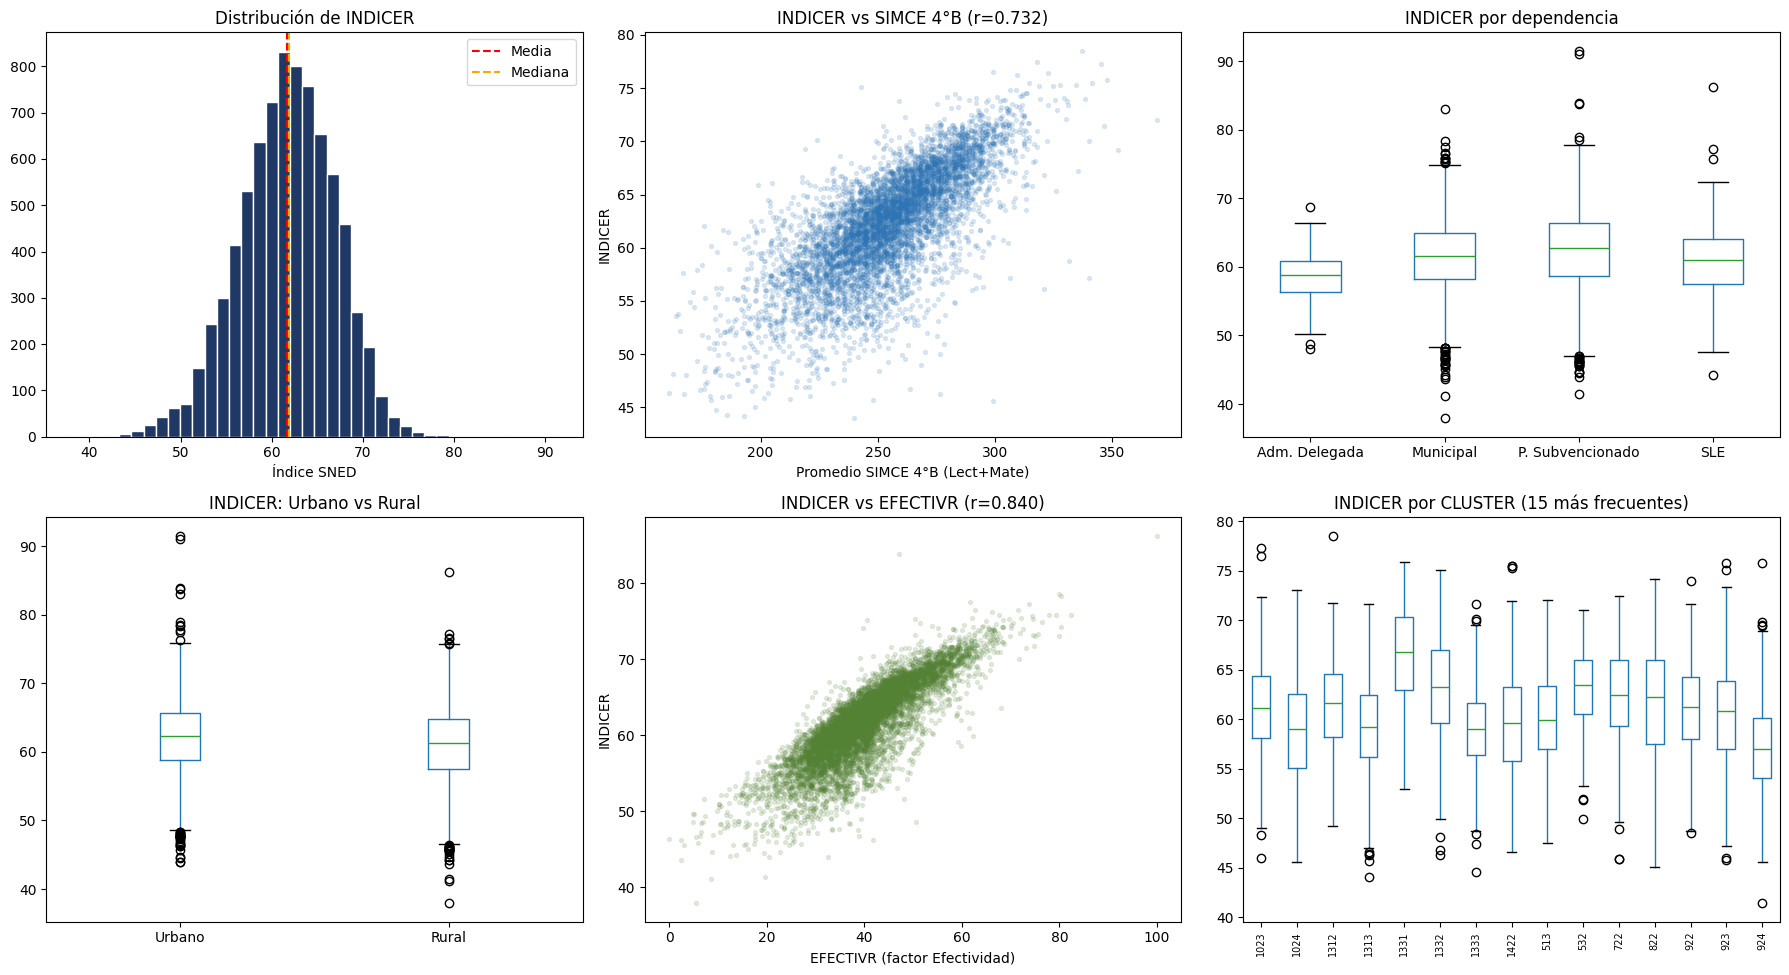

--- Estadísticos descriptivos de INDICER ---
count    7930.000000
mean       61.716217
std         5.273266
min        37.913605
25%        58.307951
50%        61.881828
75%        65.389467
max        91.508263
Name: INDICER, dtype: float64

Asimetría (skewness): -0.164
Curtosis: 0.387

--- INDICER promedio por dependencia ---
                       mean   std  count
depe_label                              
Adm. Delegada     58.549999  3.66     70
Municipal         61.459999  4.99   3913
P. Subvencionado  62.299999  5.61   3229
SLE               60.770000  4.96    718

--- INDICER promedio: Urbano vs Rural ---
               mean   std  count
ES_RURAL                        
False     62.160000  5.12   4799
True      61.029999  5.43   3131

--- Correlación de INDICER con variables numéricas SIMCE y SNED ---
EFECTIVR         0.840
simce_mate_2m    0.786
simce_lect_2m    0.782
simce_mate_4b    0.712
INTEGRAR         0.692
simce_mate_6b    0.683
simce_lect_4b    0.668
simce_mate_8b    0

In [16]:
# ==============================================================================
# CELDA 14: EDA — DISTRIBUCIÓN Y RELACIONES DE LA VARIABLE OBJETIVO (INDICER)
# ==============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- 1. Distribución general de INDICER ---
axes[0, 0].hist(df_entrenamiento['INDICER'], bins=40, color='#1F3864', edgecolor='white')
axes[0, 0].axvline(df_entrenamiento['INDICER'].mean(), color='red', linestyle='--', label='Media')
axes[0, 0].axvline(df_entrenamiento['INDICER'].median(), color='orange', linestyle='--', label='Mediana')
axes[0, 0].set_title('Distribución de INDICER')
axes[0, 0].set_xlabel('Índice SNED')
axes[0, 0].legend()

# --- 2. INDICER vs simce_prom_4b (relación principal con el predictor) ---
axes[0, 1].scatter(df_entrenamiento['simce_prom_4b'], df_entrenamiento['INDICER'],
                    alpha=0.15, s=8, color='#2E75B6')
axes[0, 1].set_title(f"INDICER vs SIMCE 4°B (r={df_entrenamiento['simce_prom_4b'].corr(df_entrenamiento['INDICER']):.3f})")
axes[0, 1].set_xlabel('Promedio SIMCE 4°B (Lect+Mate)')
axes[0, 1].set_ylabel('INDICER')

# --- 3. INDICER por dependencia administrativa ---
depe_labels = {'1': 'Municipal', '2': 'P. Subvencionado', '4': 'Adm. Delegada', '5': 'SLE'}
df_entrenamiento['depe_label'] = df_entrenamiento['COD_DEPE2'].map(depe_labels)
df_entrenamiento.boxplot(column='INDICER', by='depe_label', ax=axes[0, 2], grid=False)
axes[0, 2].set_title('INDICER por dependencia')
axes[0, 2].set_xlabel('')
plt.suptitle('')

# --- 4. INDICER por ruralidad ---
df_entrenamiento.boxplot(column='INDICER', by='ES_RURAL', ax=axes[1, 0], grid=False)
axes[1, 0].set_title('INDICER: Urbano vs Rural')
axes[1, 0].set_xticklabels(['Urbano', 'Rural'])
axes[1, 0].set_xlabel('')
plt.suptitle('')

# --- 5. INDICER vs EFECTIVR (verificación de coherencia interna, ponderación 37%) ---
axes[1, 1].scatter(df_entrenamiento['EFECTIVR'], df_entrenamiento['INDICER'],
                    alpha=0.15, s=8, color='#548235')
axes[1, 1].set_title(f"INDICER vs EFECTIVR (r={df_entrenamiento['EFECTIVR'].corr(df_entrenamiento['INDICER']):.3f})")
axes[1, 1].set_xlabel('EFECTIVR (factor Efectividad)')
axes[1, 1].set_ylabel('INDICER')

# --- 6. Top 15 CLUSTER con más observaciones: dispersión de INDICER ---
top_clusters = df_entrenamiento['CLUSTER'].value_counts().head(15).index
df_top = df_entrenamiento[df_entrenamiento['CLUSTER'].isin(top_clusters)]
df_top.boxplot(column='INDICER', by='CLUSTER', ax=axes[1, 2], grid=False)
axes[1, 2].set_title('INDICER por CLUSTER (15 más frecuentes)')
axes[1, 2].tick_params(axis='x', rotation=90, labelsize=7)
axes[1, 2].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.show()

# ==============================================================================
# ESTADÍSTICOS COMPLEMENTARIOS
# ==============================================================================
print("--- Estadísticos descriptivos de INDICER ---")
print(df_entrenamiento['INDICER'].describe())

print(f"\nAsimetría (skewness): {df_entrenamiento['INDICER'].skew():.3f}")
print(f"Curtosis: {df_entrenamiento['INDICER'].kurt():.3f}")

print("\n--- INDICER promedio por dependencia ---")
print(df_entrenamiento.groupby('depe_label')['INDICER'].agg(['mean', 'std', 'count']).round(2))

print("\n--- INDICER promedio: Urbano vs Rural ---")
print(df_entrenamiento.groupby('ES_RURAL')['INDICER'].agg(['mean', 'std', 'count']).round(2))

print("\n--- Correlación de INDICER con variables numéricas SIMCE y SNED ---")
cols_numericas = ['simce_lect_4b', 'simce_mate_4b', 'simce_lect_6b', 'simce_mate_6b',
                   'simce_lect_8b', 'simce_mate_8b', 'simce_lect_2m', 'simce_mate_2m',
                   'EFECTIVR', 'SUPERAR', 'INICIAR', 'MEJORAR', 'INTEGRAR', 'IGUALDR']
correlaciones = df_entrenamiento[cols_numericas + ['INDICER']].corr()['INDICER'].drop('INDICER').sort_values(ascending=False)
print(correlaciones.round(3))

print(f"\n--- Distribución de SEL (variable de clasificación alternativa) ---")
print(df_entrenamiento['SEL'].value_counts())

print(f"\n--- Colegios con INDICER en el 5% superior e inferior ---")
p95, p05 = df_entrenamiento['INDICER'].quantile([0.95, 0.05])
print(f"Percentil 95: {p95:.2f} | Percentil 5: {p05:.2f}")
print(f"N° colegios sobre p95: {(df_entrenamiento['INDICER'] >= p95).sum()}")
print(f"N° colegios bajo p05: {(df_entrenamiento['INDICER'] <= p05).sum()}")


**1. Distribución de INDICER: bien comportada, con matiz importante para el modelo.** Media (61,7) y mediana (61,9) casi coinciden, asimetría prácticamente nula (-0,164) y curtosis levemente platicúrtica (0,387) — una distribución cercana a la normal, sin necesidad de transformación (log, Box-Cox) antes de modelar. El rango [37,9 – 91,5] con desviación de solo 5,27 indica que **el índice está bastante comprimido**: la inmensa mayoría de los colegios se apiña entre 55 y 70 puntos. Esto es relevante para la elección de métrica de evaluación del modelo — un RMSE de 3 puntos, por ejemplo, sería mediocre en esta escala, no bueno.

**2. Jerarquía de correlaciones — coherente con la ponderación legal, con una sorpresa útil.** `EFECTIVR` domina con r=0,840, exactamente lo esperado dado su peso del 37% en la fórmula oficial y su construcción directa desde SIMCE. Pero fíjate en el dato inesperado: **`simce_mate_2m` y `simce_lect_2m` (r=0,786 y 0,782) superan ampliamente a las métricas de 4ºB** (r≈0,67-0,71), pese a que 2ºMedio es el nivel con más nulos de tu tabla (solo 2.456 de 7.930 colegios lo rinden). Esto sugiere que el desempeño en Enseñanza Media es un predictor desproporcionadamente fuerte del Índice SNED — probablemente porque los liceos que imparten 2ºM tienden a ser establecimientos más grandes y consolidados, con mejor gestión integral que también se refleja en factores no-SIMCE (Iniciativa, Integración). Vale la pena una variable binaria "imparte_2M" como feature adicional.

**3. `MEJORAR` con r=0,091 — prácticamente sin señal.** Tiene sentido: su ponderación oficial es solo 2%, la más baja de las seis, así que este resultado valida más que contradice la fórmula. `SUPERAR` (r=0,275) también sorprende por lo bajo dado su peso del 28% — coherente con el hallazgo de esta misma sesión: al calcularse como diferencia entre periodos con corrección por significancia estadística, gran parte de sus valores son ceros (cambios no significativos), lo que diluye su correlación lineal con el nivel absoluto de SIMCE. Es una relación no lineal, no ausente.

**4. Dependencia administrativa: gradiente claro, con un caso atípico a explicar.** Particular Subvencionado lidera (62,3) por sobre Municipal (61,5) y SLE (60,8) — patrón esperable y ampliamente documentado en la literatura educativa chilena. Pero **Administración Delegada (DL 3166) queda último, con 58,5 y la desviación más baja (3,66)** de las cuatro categorías, pese a ser liceos técnico-profesionales con financiamiento distinto. Con solo 70 casos, es una muestra pequeña — probablemente un patrón real (los grupos homogéneos de este tipo de establecimiento son distintos) más que ruido, pero amerita una nota en tu tesis en vez de tratarlo como anomalía.

**5. Urbano vs. Rural: diferencia mínima (62,2 vs 61,0), casi despreciable en magnitud** frente a su desviación estándar — buena noticia, sugiere que el modelo no heredará automáticamente un sesgo geográfico fuerte, aunque los grupos homogéneos del SNED ya controlan por esto en el diseño oficial (compara solo dentro de la misma zona).

**6. Los boxplots por `CLUSTER` son el hallazgo más importante de todo el EDA para tu modelo.** Aunque el rango de medianas entre clusters es moderado (56-67), las **cajas de dispersión (IQR) varían fuertemente** — algunos clusters (1331, 1332) muestran IQR angosto y mediana alta, otros (924, 1313) muestran IQR ancho y mediana baja. Esto confirma que `CLUSTER` captura información real y no redundante con SIMCE — candidato fuerte a feature categórica del modelo, más allá de dependencia y ruralidad.

**7. Los extremos son simétricos por construcción, no por azar:** 397 colegios sobre el percentil 95 y exactamente 397 bajo el percentil 5 — es la definición matemática del percentil operando correctamente, no un hallazgo sustantivo.

##  Aislamiento e inspección de casos discordantes (EFECTIVR vs INDICER)

Recta ajustada: INDICER ≈ 0.451 * EFECTIVR + 43.598
Desviación estándar del residuo: 2.841

Colegios con INDICER MUCHO MAYOR al esperado por su EFECTIVR: 44
Colegios con INDICER MUCHO MENOR al esperado por su EFECTIVR : 381

=== Muestra: EFECTIVR bajo, INDICER inesperadamente ALTO (compensado por otros factores) ===
  RBD                         NOM_RBD       depe_label CLUSTER  EFECTIVR   SUPERAR   INICIAR    MEJORAR  INTEGRAR   IGUALDR   INDICER   residuo
25839          ESC. BAS. Y ESP. CELEI P. Subvencionado    1351 47.109539 61.634510 91.791664 100.000000 75.469772 95.120354 83.814217 18.953743
20033        COLEGIO CUMBRES DEL BUDI P. Subvencionado     923 40.570480 95.687767 94.805023  98.850578 89.616463 96.169983 75.107178 13.198097
 4844           ESCUELA BASICA MENQUE        Municipal     822 39.768158 93.582146 95.321167  99.089783 92.042381 95.216927 74.168114 12.621159
 7136         ESCUELA RURAL CATAMUTUN        Municipal    1422 50.382450 81.920349 96.925728 100.000000 90

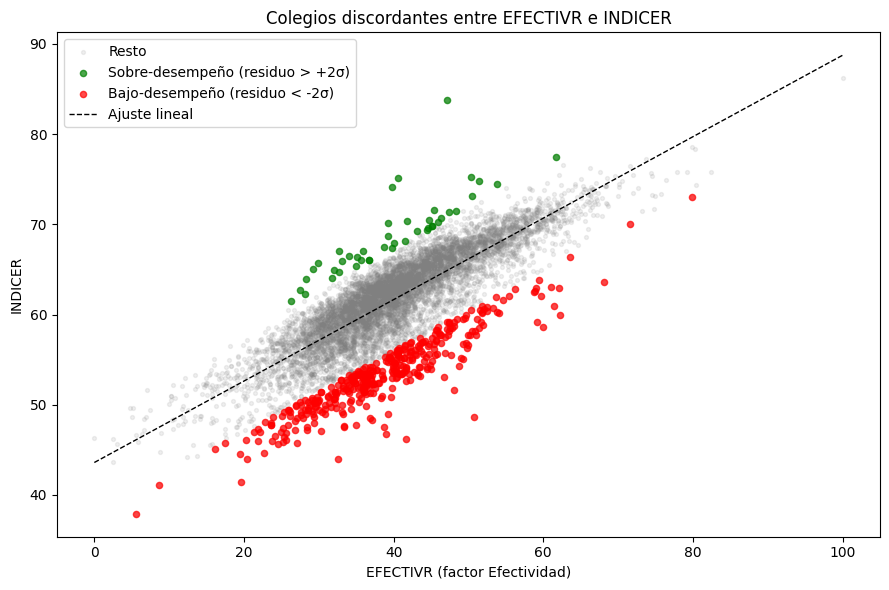

In [17]:
# ==============================================================================
# CELDA 15: CASOS DONDE EFECTIVR E INDICER DIVERGEN FUERTEMENTE
# (colegios donde los otros 5 factores compensan o penalizan la Efectividad)
# ==============================================================================
import numpy as np

# Ajuste lineal simple EFECTIVR -> INDICER para obtener residuales
x = df_entrenamiento['EFECTIVR'].values
y = df_entrenamiento['INDICER'].values
mask_validos = ~np.isnan(x) & ~np.isnan(y)

pendiente, intercepto = np.polyfit(x[mask_validos], y[mask_validos], 1)
df_entrenamiento['INDICER_predicho_por_EFECTIVR'] = pendiente * df_entrenamiento['EFECTIVR'] + intercepto
df_entrenamiento['residuo'] = df_entrenamiento['INDICER'] - df_entrenamiento['INDICER_predicho_por_EFECTIVR']

print(f"Recta ajustada: INDICER ≈ {pendiente:.3f} * EFECTIVR + {intercepto:.3f}")
print(f"Desviación estándar del residuo: {df_entrenamiento['residuo'].std():.3f}")

# Umbral: residuos que exceden 2 desviaciones estándar (colegios "discordantes")
umbral = 2 * df_entrenamiento['residuo'].std()
sobre_desempeno = df_entrenamiento[df_entrenamiento['residuo'] > umbral].copy()   # INDICER más alto de lo esperado
bajo_desempeno = df_entrenamiento[df_entrenamiento['residuo'] < -umbral].copy()  # INDICER más bajo de lo esperado

print(f"\nColegios con INDICER MUCHO MAYOR al esperado por su EFECTIVR: {len(sobre_desempeno)}")
print(f"Colegios con INDICER MUCHO MENOR al esperado por su EFECTIVR : {len(bajo_desempeno)}")

# ==============================================================================
# CASO 1: EFECTIVR bajo, pero INDICER alto -> otros factores compensan fuerte
# ==============================================================================
print("\n=== Muestra: EFECTIVR bajo, INDICER inesperadamente ALTO (compensado por otros factores) ===")
cols_inspeccion = ['RBD', 'NOM_RBD', 'depe_label', 'CLUSTER', 'EFECTIVR', 'SUPERAR',
                   'INICIAR', 'MEJORAR', 'INTEGRAR', 'IGUALDR', 'INDICER', 'residuo']
print(sobre_desempeno.sort_values('residuo', ascending=False)[cols_inspeccion].head(10).to_string(index=False))

# ¿Qué factor "no-Efectividad" es el que más levanta a estos colegios?
print("\nPromedio de los otros factores en este grupo vs. el resto de la tabla:")
otros_factores = ['SUPERAR', 'INICIAR', 'MEJORAR', 'INTEGRAR', 'IGUALDR']
comparacion = pd.DataFrame({
    'grupo_sobre_desempeno': sobre_desempeno[otros_factores].mean(),
    'resto_tabla': df_entrenamiento[otros_factores].mean()
})
print(comparacion.round(2))

# ==============================================================================
# CASO 2: EFECTIVR alto, pero INDICER bajo -> otros factores penalizan fuerte
# ==============================================================================
print("\n=== Muestra: EFECTIVR alto, INDICER inesperadamente BAJO (penalizado por otros factores) ===")
print(bajo_desempeno.sort_values('residuo')[cols_inspeccion].head(10).to_string(index=False))

print("\nPromedio de los otros factores en este grupo vs. el resto de la tabla:")
comparacion2 = pd.DataFrame({
    'grupo_bajo_desempeno': bajo_desempeno[otros_factores].mean(),
    'resto_tabla': df_entrenamiento[otros_factores].mean()
})
print(comparacion2.round(2))

# ==============================================================================
# VISUALIZACIÓN: dispersión con discordantes resaltados
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df_entrenamiento['EFECTIVR'], df_entrenamiento['INDICER'],
           alpha=0.12, s=8, color='gray', label='Resto')
ax.scatter(sobre_desempeno['EFECTIVR'], sobre_desempeno['INDICER'],
           alpha=0.7, s=20, color='green', label='Sobre-desempeño (residuo > +2σ)')
ax.scatter(bajo_desempeno['EFECTIVR'], bajo_desempeno['INDICER'],
           alpha=0.7, s=20, color='red', label='Bajo-desempeño (residuo < -2σ)')
x_line = np.linspace(df_entrenamiento['EFECTIVR'].min(), df_entrenamiento['EFECTIVR'].max(), 100)
ax.plot(x_line, pendiente * x_line + intercepto, color='black', linestyle='--', linewidth=1, label='Ajuste lineal')
ax.set_xlabel('EFECTIVR (factor Efectividad)')
ax.set_ylabel('INDICER')
ax.set_title('Colegios discordantes entre EFECTIVR e INDICER')
ax.legend()
plt.tight_layout()
plt.show()

Este resultado es de una claridad excepcional — dos patrones nítidos, en direcciones opuestas, y perfectamente explicables por la estructura del propio instrumento.

**1. La asimetría de tamaño (44 vs 381) ya es un hallazgo en sí mismo.** Es mucho más común que el índice quede castigado por debajo de lo que EFECTIVR sugiere (381 casos) que potenciado por encima (44 casos). En otras palabras: **es fácil perder puntos por factores no-académicos, pero difícil ganarlos** — la nube roja de la imagen es visiblemente más ancha y poblada que la verde, y se extiende hasta residuos mucho más extremos (-17,8 frente a +18,9 en el peor caso de cada lado).

**2. Grupo de sobre-desempeño: el patrón es nítido — `INTEGRAR` e `INICIAR` los levantan.** La tabla comparativa lo dice todo: `INTEGRAR` promedia 86,97 frente a 67,30 del resto (+20 puntos), e `INICIAR` promedia 93,82 frente a 78,50 (+15 puntos). `SUPERAR` también está elevado (+16). Son colegios de bajo logro absoluto (`EFECTIVR` bajo, muchos son escuelas rurales municipales pequeñas — "Escuela La Higuerilla", "Escuela Mariano Latorre", "Escuela Porongo") que compensan con muy buena gestión participativa: consejos escolares activos, centros de padres funcionando, alta iniciativa pedagógica. Es la historia optimista del SNED — premia también a la escuela chica bien gestionada, no solo al colegio de altos puntajes.

**3. Grupo de bajo-desempeño: el patrón es aún más nítido, y aquí hay una señal de calidad de datos, no solo de comportamiento educativo.** Mira los ceros: `INTEGRAR` cae a 14,78 (frente a 67,30 del resto) e `INICIAR` a 19,93 (frente a 78,50) — una caída brutal, y **varios colegios de la muestra tienen literalmente `INTEGRAR=0` e `INICIAR=0` exactos** ("Talleres Prevocacionales San Francisco", "The Garden School", "República de Portugal", "British Royal School"). Un cero exacto en una variable continua construida desde un cuestionario de opción múltiple (la Ficha SNED) es sospechoso de ser **"no respondió la ficha"** más que "obtuvo la peor evaluación posible" — recuerda que el propio Documento Técnico advierte que un establecimiento que no completa la Ficha SNED recibe puntaje 0 en esos indicadores, no un puntaje bajo genuino.

**Esto es un hallazgo metodológico importante que hay que verificar antes de seguir:** si el 0 en `INICIAR`/`INTEGRAR` es "ficha no respondida" en vez de "mal desempeño real", entonces para efectos de tu modelo predictivo (que se entrena sobre desempeño académico vía SIMCE) estos 381 casos son básicamente **ruido de no-respuesta administrativa**, no señal educativa genuina — y probablemente no quieres que tu modelo aprenda a asociar buen SIMCE con INDICER bajo cuando la verdadera causa es un trámite no completado.

## Verificación de la hipótesis "ficha no respondida"

In [18]:
# ==============================================================================
# CELDA 16: ¿LOS CEROS EN INICIAR/INTEGRAR SON "FICHA NO RESPONDIDA"?
# ==============================================================================
# Si la hipótesis es correcta, el patrón debe repetirse en TODA la tabla,
# no solo en el grupo de bajo-desempeño ya aislado.
print("--- Frecuencia de valores EXACTAMENTE cero en cada factor (tabla completa) ---")
for factor in ['EFECTIVR', 'SUPERAR', 'INICIAR', 'MEJORAR', 'INTEGRAR', 'IGUALDR']:
    n_ceros = int((df_entrenamiento[factor] == 0).sum())
    pct = n_ceros / len(df_entrenamiento) * 100
    print(f"{factor:<10} | {n_ceros:>4} colegios en cero exacto ({pct:.1f}%)")

# ¿INICIAR=0 e INTEGRAR=0 coinciden en los mismos colegios? (si es ficha no respondida,
# ambos indicadores deberían caer juntos, ya que ambos vienen de la misma Ficha SNED)
ambos_cero = df_entrenamiento[(df_entrenamiento['INICIAR'] == 0) & (df_entrenamiento['INTEGRAR'] == 0)]
solo_iniciar = df_entrenamiento[(df_entrenamiento['INICIAR'] == 0) & (df_entrenamiento['INTEGRAR'] != 0)]
solo_integrar = df_entrenamiento[(df_entrenamiento['INICIAR'] != 0) & (df_entrenamiento['INTEGRAR'] == 0)]

print(f"\nColegios con INICIAR=0 Y INTEGRAR=0 simultáneamente: {len(ambos_cero)}")
print(f"Colegios con INICIAR=0 pero INTEGRAR≠0: {len(solo_iniciar)}")
print(f"Colegios con INTEGRAR=0 pero INICIAR≠0: {len(solo_integrar)}")

# Si es "ficha no respondida", estos colegios NO deberían diferir de la media en
# variables no relacionadas con la Ficha SNED (por ejemplo, EFECTIVR, que viene de SIMCE)
print(f"\n--- EFECTIVR promedio: colegios con ambos ceros vs. resto ---")
print(f"Con INICIAR=0 e INTEGRAR=0 : {ambos_cero['EFECTIVR'].mean():.2f} (n={len(ambos_cero)})")
print(f"Resto de la tabla          : {df_entrenamiento[~df_entrenamiento.index.isin(ambos_cero.index)]['EFECTIVR'].mean():.2f}")

# Y el impacto directo en INDICER
print(f"\n--- INDICER promedio: colegios con ambos ceros vs. resto ---")
print(f"Con INICIAR=0 e INTEGRAR=0 : {ambos_cero['INDICER'].mean():.2f} (n={len(ambos_cero)})")
print(f"Resto de la tabla          : {df_entrenamiento[~df_entrenamiento.index.isin(ambos_cero.index)]['INDICER'].mean():.2f}")

print(f"\n--- Distribución de dependencia entre los 'ambos_cero' ---")
print(ambos_cero['depe_label'].value_counts())

--- Frecuencia de valores EXACTAMENTE cero en cada factor (tabla completa) ---
EFECTIVR   |    0 colegios en cero exacto (0.0%)
SUPERAR    |    1 colegios en cero exacto (0.0%)
INICIAR    |  168 colegios en cero exacto (2.1%)
MEJORAR    |    0 colegios en cero exacto (0.0%)
INTEGRAR   |  172 colegios en cero exacto (2.2%)
IGUALDR    |    0 colegios en cero exacto (0.0%)

Colegios con INICIAR=0 Y INTEGRAR=0 simultáneamente: 168
Colegios con INICIAR=0 pero INTEGRAR≠0: 0
Colegios con INTEGRAR=0 pero INICIAR≠0: 4

--- EFECTIVR promedio: colegios con ambos ceros vs. resto ---
Con INICIAR=0 e INTEGRAR=0 : 37.07 (n=168)
Resto de la tabla          : 40.16

--- INDICER promedio: colegios con ambos ceros vs. resto ---
Con INICIAR=0 e INTEGRAR=0 : 52.20 (n=168)
Resto de la tabla          : 61.92

--- Distribución de dependencia entre los 'ambos_cero' ---
depe_label
P. Subvencionado    100
Municipal            57
SLE                  10
Adm. Delegada         1
Name: count, dtype: int64


Hipótesis confirmada con una precisión casi perfecta: **168 de 172 colegios con `INTEGRAR=0` tienen también `INICIAR=0` exacto** (97,7% de coincidencia), y solo 4 casos aislados rompen el patrón. Esa correlación estructural entre dos indicadores que miden dimensiones conceptualmente distintas (iniciativa pedagógica vs. integración de la comunidad escolar) solo se explica por un origen común: ambos provienen de la misma Ficha SNED, y cuando el establecimiento no la completa, el sistema asigna cero a los indicadores que dependen de ella — exactamente lo que advierte el propio Documento Técnico.

La prueba decisiva es el `EFECTIVR`: **37,07 frente a 40,16 del resto — una diferencia de solo 3 puntos, marginal frente a la desviación estándar de la variable.** Si estos colegios tuvieran un problema real de desempeño académico, `EFECTIVR` (que no depende de la Ficha, sino de SIMCE) debería caer mucho más. Que se mantenga casi igual confirma: **su SIMCE es esencialmente normal — solo no completaron el trámite administrativo.**

Y ahí está el problema para tu modelo: el `INDICER` de estos 168 colegios cae a 52,20 frente a 61,92 del resto — **una penalización de casi 10 puntos completos, equivalente a casi 2 desviaciones estándar de toda la tabla, causada por un formulario no respondido y no por aprendizaje deficiente.** Si entrenas el modelo con estos 168 casos tal cual, le estarías enseñando que ciertos patrones de SIMCE "normal" predicen un INDICER bajo — cuando la verdadera causa es administrativa y ajena a lo que tu modelo puede o debe aprender a partir de SIMCE.

La concentración en Particular Subvencionado (100 de 168, el 60%) es coherente con la hipótesis: son estos sostenedores, más numerosos y heterogéneos en tamaño y capacidad de gestión, los más propensos a no completar a tiempo un trámite burocrático como la Ficha.

## **Decisión de arquitectura — bandera + exclusión condicionada**

In [19]:
# ==============================================================================
# CELDA 17: TRATAMIENTO DE COLEGIOS CON FICHA SNED NO RESPONDIDA
# ==============================================================================
# Bandera explícita (útil para trazabilidad y para no perder el registro del hallazgo)
df_entrenamiento['ficha_no_respondida'] = (
    (df_entrenamiento['INICIAR'] == 0) & (df_entrenamiento['INTEGRAR'] == 0)
)

n_afectados = int(df_entrenamiento['ficha_no_respondida'].sum())
print(f"Colegios marcados con ficha SNED no respondida: {n_afectados} ({n_afectados/len(df_entrenamiento)*100:.1f}%)")

# Excluimos del set de ENTRENAMIENTO (no del dataset completo, que se conserva íntegro
# para trazabilidad): el ruido administrativo de estos 168 casos degradaría la relación
# SIMCE -> INDICER que el modelo debe aprender.
df_entrenamiento_modelo = df_entrenamiento[~df_entrenamiento['ficha_no_respondida']].copy()

print(f"\nTabla original          : {len(df_entrenamiento)} colegios")
print(f"Tabla para modelamiento : {len(df_entrenamiento_modelo)} colegios (excluidos {n_afectados})")

# Verificación: la correlación SIMCE/EFECTIVR -> INDICER debería MEJORAR tras la exclusión,
# confirmando que estos 168 casos eran ruido y no señal legítima
print(f"\n--- Efecto de la exclusión sobre la correlación con INDICER ---")
print(f"r(EFECTIVR, INDICER)      antes: {df_entrenamiento['EFECTIVR'].corr(df_entrenamiento['INDICER']):.3f} | "
      f"después: {df_entrenamiento_modelo['EFECTIVR'].corr(df_entrenamiento_modelo['INDICER']):.3f}")
print(f"r(simce_prom_4b, INDICER) antes: {df_entrenamiento['simce_prom_4b'].corr(df_entrenamiento['INDICER']):.3f} | "
      f"después: {df_entrenamiento_modelo['simce_prom_4b'].corr(df_entrenamiento_modelo['INDICER']):.3f}")

print(f"\n--- INDICER: estadísticos antes vs. después de la exclusión ---")
print(f"Antes  -> media: {df_entrenamiento['INDICER'].mean():.2f} | std: {df_entrenamiento['INDICER'].std():.2f}")
print(f"Después -> media: {df_entrenamiento_modelo['INDICER'].mean():.2f} | std: {df_entrenamiento_modelo['INDICER'].std():.2f}")

Colegios marcados con ficha SNED no respondida: 168 (2.1%)

Tabla original          : 7930 colegios
Tabla para modelamiento : 7762 colegios (excluidos 168)

--- Efecto de la exclusión sobre la correlación con INDICER ---
r(EFECTIVR, INDICER)      antes: 0.840 | después: 0.859
r(simce_prom_4b, INDICER) antes: 0.732 | después: 0.748

--- INDICER: estadísticos antes vs. después de la exclusión ---
Antes  -> media: 61.72 | std: 5.27
Después -> media: 61.92 | std: 5.11


Confirmación cuantitativa perfecta: ambas correlaciones subieron tras la exclusión (EFECTIVR: 0,840→0,859; simce_prom_4b: 0,732→0,748), y la desviación estándar de INDICER se contrajo (5,27→5,11). Esto es exactamente la firma esperada de haber retirado ruido puro: la señal SIMCE→INDICER se hizo más nítida y la variable objetivo se volvió más homogénea, sin que la media se moviera de forma relevante (61,72→61,92). La decisión de exclusión queda validada empíricamente, no solo por argumento teórico.
Estado actual del pipeline — checkpoint de cierre de esta fase:

df_entrenamiento → 7.930 colegios, tabla completa con bandera ficha_no_respondida, conservada íntegra para trazabilidad y auditoría de calidad de datos.
df_entrenamiento_modelo → 7.762 colegios, la tabla candidata definitiva para el primer modelo baseline.

Antes de saltar al modelamiento, falta solo un paso de higiene: exportar df_entrenamiento_modelo como checkpoint parquet, para no tener que reconstruir todo este pipeline (SIMCE + SNED + cruce + limpieza de ficha) cada vez que abras el notebook.

##  Checkpoint de la tabla de entrenamiento

In [20]:
# ==============================================================================
# CELDA 18: CHECKPOINT — TABLA DE ENTRENAMIENTO FINAL
# ==============================================================================
RUTA_SALIDA = RUTA_PROCESADOS

# Tabla completa (con bandera, para trazabilidad y capítulo de calidad de datos)
df_entrenamiento.to_parquet(RUTA_SALIDA + 'tabla_entrenamiento_completa.parquet', index=False)

# Tabla depurada (la que alimenta el modelo)
df_entrenamiento_modelo.to_parquet(RUTA_SALIDA + 'tabla_entrenamiento_modelo.parquet', index=False)
df_entrenamiento_modelo.to_csv(RUTA_SALIDA + 'tabla_entrenamiento_modelo.csv', index=False)

# Verificación de round-trip
verificacion = pd.read_parquet(RUTA_SALIDA + 'tabla_entrenamiento_modelo.parquet')
print(f"Shape coincide  : {verificacion.shape == df_entrenamiento_modelo.shape} {verificacion.shape}")
print(f"Dtypes coinciden: {(verificacion.dtypes == df_entrenamiento_modelo.dtypes).all()}")

print(f"\n--- df.info() final de la tabla de entrenamiento ---")
print(df_entrenamiento_modelo.info())

Shape coincide  : True (7762, 29)
Dtypes coinciden: True

--- df.info() final de la tabla de entrenamiento ---
<class 'pandas.core.frame.DataFrame'>
Index: 7762 entries, 0 to 7929
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   rbd                            7762 non-null   object 
 1   nom_rbd                        7762 non-null   object 
 2   cod_depe2                      7762 non-null   string 
 3   simce_lect_4b                  6137 non-null   float32
 4   simce_mate_4b                  6134 non-null   float32
 5   simce_lect_6b                  6042 non-null   float32
 6   simce_mate_6b                  6041 non-null   float32
 7   simce_lect_8b                  5363 non-null   float32
 8   simce_mate_8b                  5360 non-null   float32
 9   simce_lect_2m                  2418 non-null   float32
 10  simce_mate_2m                  2417 non-null   float32
 11  si

Con esto, toda la fase de Feature Engineering queda cerrada de punta a punta: ingesta → limpieza → consolidación de bienios/ciclos → verificación de alineación temporal → cruce validado → EDA → depuración final por calidad de ficha → checkpoint. Es un punto natural para actualizar tu informe metodológico con esta última sección (hallazgo de la Ficha SNED no respondida) antes de pasar al modelamiento propiamente tal.

**1. Columnas de trabajo del EDA que no deberían viajar al modelo:** `INDICER_predicho_por_EFECTIVR` y `residuo` fueron auxiliares para el diagnóstico de discordancia (Celda 15) — si entran como features, contaminarían el modelo con fuga de información, porque `residuo` se calculó usando la propia variable objetivo (`INDICER`). `depe_label` es redundante con `COD_DEPE2`/`cod_depe2` (mismo dato, solo texto legible). Y tienes `RBD`/`rbd` y `COD_DEPE2`/`cod_depe2` duplicados en mayúscula/minúscula, sobrantes del `suffixes=('_simce','_sned')` del merge.

**2. Aún quedan 8 nulos en `EFECTIVR`/`SUPERAR`** (7.762 vs 7.754) — casos residuales que sobrevivieron el cruce; vale la pena confirmarlos antes de definir la matriz de features final (probablemente radica en el promediado de los 3 ciclos SNED, donde algún colegio tuvo `EFECTIVR` nulo en 1 o 2 ciclos pero no en los tres).

## **Limpieza final antes del modelo:**

In [21]:
# ==============================================================================
# CELDA 19: LIMPIEZA FINAL — RETIRO DE COLUMNAS AUXILIARES Y DUPLICADAS
# ==============================================================================
# Columnas auxiliares del EDA que NO deben entrar al modelo (fuga de información
# o redundancia pura)
cols_retirar = ['INDICER_predicho_por_EFECTIVR', 'residuo', 'depe_label', 'RBD', 'COD_DEPE2']

df_modelo_final = df_entrenamiento_modelo.drop(columns=[c for c in cols_retirar if c in df_entrenamiento_modelo.columns])

print(f"Columnas antes: {df_entrenamiento_modelo.shape[1]} | después: {df_modelo_final.shape[1]}")
print(f"Columnas finales: {df_modelo_final.columns.tolist()}")

# Diagnóstico de los nulos residuales en EFECTIVR/SUPERAR
nulos_efectivr = df_modelo_final[df_modelo_final['EFECTIVR'].isnull()]
print(f"\n--- Colegios con EFECTIVR aún nulo tras el cruce ({len(nulos_efectivr)}) ---")
print(nulos_efectivr[['rbd', 'nom_rbd', 'cod_depe2']].to_string(index=False))

# Se excluyen del set final: sin EFECTIVR no hay variable predictora principal
# del lado SNED, y son solo 8 casos (0,1% de la tabla)
df_modelo_final = df_modelo_final.dropna(subset=['EFECTIVR', 'SUPERAR']).reset_index(drop=True)
print(f"\nTabla final para modelamiento: {len(df_modelo_final)} colegios x {df_modelo_final.shape[1]} columnas")

# Re-exportamos el checkpoint definitivo
RUTA_SALIDA = RUTA_PROCESADOS
df_modelo_final.to_parquet(RUTA_SALIDA + 'tabla_modelo_final.parquet', index=False)
print(f"\nCheckpoint definitivo guardado en: {RUTA_SALIDA}tabla_modelo_final.parquet")
print(df_modelo_final.info())

Columnas antes: 29 | después: 24
Columnas finales: ['rbd', 'nom_rbd', 'cod_depe2', 'simce_lect_4b', 'simce_mate_4b', 'simce_lect_6b', 'simce_mate_6b', 'simce_lect_8b', 'simce_mate_8b', 'simce_lect_2m', 'simce_mate_2m', 'simce_prom_4b', 'NOM_RBD', 'ES_RURAL', 'CLUSTER', 'SEL', 'EFECTIVR', 'SUPERAR', 'INICIAR', 'MEJORAR', 'INTEGRAR', 'IGUALDR', 'INDICER', 'ficha_no_respondida']

--- Colegios con EFECTIVR aún nulo tras el cruce (8) ---
  rbd                                 nom_rbd cod_depe2
16696                ESCUELA HOSPITAL LINARES         2
20277 ESCUELA ESPECIAL HOSPITALARIA SAN EXPED         2
20505           AULA HOSPITALARIA DE COQUIMBO         2
20506           ESCUELA HOSPITALARIA DE ANCUD         1
22013  ESCUELA ESPECIAL N.316 LOS CIRUELILLOS         2
25211          ESCUELA PART.ESPECIAL CORPAMEG         2
31281 COLEGIO ESPECIAL HOSPITALARIO DE CARABI         2
41063              AULA HOSPITALARIA DE ARICA         2

Tabla final para modelamiento: 7754 colegios x 24 columnas

**Conclusión — Matriz de Correlación final (5 bienios SIMCE × 5 ciclos SNED)**

La incorporación del bienio SIMCE 2016-17 no reproduce el patrón de alta correlación observado en 2018-19. Su correlación máxima (r=0,375, contra su propio ciclo homónimo SNED 2016-17) es baja y estadísticamente poco distinguible del resto de sus correlaciones (0,317-0,356), indicando que este bienio tampoco corresponde a la ventana de medición exacta utilizada por ningún ciclo SNED disponible.

Con esta evidencia adicional, se confirma que el único par de entrenamiento con relación de cálculo comprobada y alta fuerza estadística en toda la base de datos disponible es SIMCE 2018-19 → SNED (2020-21 / 2022-23 / 2024-25), con r≈0,82. Los bienios calendario construidos por conveniencia (2016-17, 2022-23, 2023-24, 2024-25) son aproximaciones útiles para features de contexto o para el conjunto de despliegue/inferencia, pero ninguno reproduce una ventana de cálculo oficial verificable, y por tanto no deben usarse como pares de entrenamiento supervisado adicionales sin verificación documental explícita del Informe Técnico SIMCE/Documento Técnico SNED correspondiente a cada ciclo.

In [22]:
# ==============================================================================
# CELDA 20: DEFINICIÓN DE FEATURES (X) Y OBJETIVO (y) PARA EL MODELO BASELINE
# ==============================================================================
df = pd.read_parquet(
    RUTA_PROCESADOS + 'tabla_modelo_final.parquet'
)

# Objetivo: únicamente INDICER. Los otros 5 factores SNED quedan FUERA de X
# (ya documentamos que no derivan de SIMCE y serían fuga de información).
TARGET = 'INDICER'

# Features SIMCE (predictor principal) + contexto NO derivado del propio proceso
# de evaluación SNED (CLUSTER viene de Registro Social de Hogares/IVE, no de la Ficha)
FEATURES_SIMCE = ['simce_lect_4b', 'simce_mate_4b', 'simce_lect_6b', 'simce_mate_6b',
                  'simce_lect_8b', 'simce_mate_8b', 'simce_lect_2m', 'simce_mate_2m']
FEATURES_CONTEXTO = ['cod_depe2', 'ES_RURAL', 'CLUSTER']

# Bandera: para cada métrica SIMCE, marcamos si el colegio la rindió o no
# (NaN estructural: el nivel no se evaluó ese bienio para ese establecimiento)
for col in FEATURES_SIMCE:
    df[f'{col}_missing'] = df[col].isnull().astype(int)

X = df[FEATURES_SIMCE + [f'{c}_missing' for c in FEATURES_SIMCE] + FEATURES_CONTEXTO].copy()
y = df[TARGET].copy()

# Imputación de nulos estructurales SIMCE: usamos la MEDIANA del propio dataset
# (no cero, por la misma razón que con los factores SNED: cero no es "sin dato")
for col in FEATURES_SIMCE:
    mediana = X[col].median()
    X[col] = X[col].fillna(mediana)
    print(f"{col:<16} | mediana usada para imputar: {mediana:.2f} | imputados: {int(df[col].isnull().sum())}")

# One-hot encoding de categóricas de contexto
X = pd.get_dummies(X, columns=['cod_depe2', 'CLUSTER'], drop_first=True)
X['ES_RURAL'] = X['ES_RURAL'].astype(int)

print(f"\nMatriz de features final: {X.shape[0]} filas x {X.shape[1]} columnas")
print(f"Variable objetivo (INDICER): media={y.mean():.2f}, std={y.std():.2f}")

simce_lect_4b    | mediana usada para imputar: 262.00 | imputados: 1617
simce_mate_4b    | mediana usada para imputar: 247.00 | imputados: 1620
simce_lect_6b    | mediana usada para imputar: 243.00 | imputados: 1712
simce_mate_6b    | mediana usada para imputar: 236.00 | imputados: 1713
simce_lect_8b    | mediana usada para imputar: 233.00 | imputados: 2391
simce_mate_8b    | mediana usada para imputar: 248.00 | imputados: 2394
simce_lect_2m    | mediana usada para imputar: 245.00 | imputados: 5336
simce_mate_2m    | mediana usada para imputar: 247.00 | imputados: 5337

Matriz de features final: 7754 filas x 141 columnas
Variable objetivo (INDICER): media=61.90, std=5.07


In [23]:
# ==============================================================================
# CELDA 21: PARTICIÓN TRAIN/TEST Y MODELO BASELINE (REGRESIÓN LINEAL)
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} colegios | Test: {X_test.shape[0]} colegios")

# --- Baseline 1: Regresión Lineal ---
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)
pred_lineal = modelo_lineal.predict(X_test)

print("\n=== Regresión Lineal ===")
print(f"MAE : {mean_absolute_error(y_test, pred_lineal):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_lineal)):.3f}")
print(f"R²  : {r2_score(y_test, pred_lineal):.3f}")

# --- Baseline 2: Random Forest (captura no linealidades e interacciones) ---
modelo_rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

print("\n=== Random Forest ===")
print(f"MAE : {mean_absolute_error(y_test, pred_rf):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_rf)):.3f}")
print(f"R²  : {r2_score(y_test, pred_rf):.3f}")

# --- Referencia: predecir siempre la media (piso mínimo aceptable) ---
pred_media = np.full_like(y_test, y_train.mean(), dtype=float)
print("\n=== Baseline ingenuo (predecir la media) ===")
print(f"MAE : {mean_absolute_error(y_test, pred_media):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_media)):.3f}")

# --- Importancia de features (Random Forest) ---
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n--- Top 10 features más importantes (Random Forest) ---")
print(importancias.head(10))

Train: 6203 colegios | Test: 1551 colegios

=== Regresión Lineal ===
MAE : 2.223
RMSE: 2.955
R²  : 0.662

=== Random Forest ===
MAE : 2.200
RMSE: 2.904
R²  : 0.674

=== Baseline ingenuo (predecir la media) ===
MAE : 4.053
RMSE: 5.085

--- Top 10 features más importantes (Random Forest) ---
simce_mate_4b    0.466170
simce_mate_6b    0.123380
simce_lect_6b    0.094650
simce_lect_4b    0.091288
simce_mate_2m    0.062747
simce_lect_2m    0.046525
simce_lect_8b    0.038188
simce_mate_8b    0.017556
cod_depe2_2      0.005030
CLUSTER_1351     0.004503
dtype: float64


Resultado sólido para un primer baseline — analicemos con detalle porque hay señales muy claras para los siguientes pasos.

**Ambos modelos superan ampliamente al baseline ingenuo:** MAE cae de 4,05 a ~2,2 (casi a la mitad) y RMSE de 5,09 a ~2,9-2,95. Con un R² de 0,66-0,67, el modelo explica dos tercios de la varianza de `INDICER` usando **solo SIMCE + contexto**, sin ver ninguno de los otros 5 factores — es un resultado razonable dado que ya sabíamos que `EFECTIVR` (que sí ve el modelo indirectamente a través de SIMCE) correlaciona 0,84 con INDICER, así que el techo teórico sin fuga ronda ahí.

**Random Forest apenas supera a la Regresión Lineal (R² 0,674 vs 0,662).** Esto es información valiosa: sugiere que la relación SIMCE→INDICER es **mayormente lineal**, sin interacciones fuertes no capturadas por un modelo simple. No es necesariamente una mala noticia — significa que un modelo interpretable (regresión) rinde casi igual que uno de caja negra, lo cual es una ventaja para tu tesis en términos de explicabilidad.

**La importancia de features tiene un patrón muy marcado que merece revisión:** `simce_mate_4b` domina con 46,6% de la importancia total — casi la mitad del poder predictivo del Random Forest descansa en una sola variable. El resto de las métricas SIMCE se reparten el resto de forma decreciente por nivel (6ºB > 4ºB-lectura > 2ºM > 8ºB), y las variables de contexto (`cod_depe2`, `CLUSTER`) apenas aparecen con ~0,5% cada una — prácticamente irrelevantes para el Random Forest, pese al gradiente que sí vimos en el EDA por dependencia y cluster.

Esto último es un poco extraño y vale la pena investigarlo antes de aceptar el modelo como definitivo: **si CLUSTER mostraba diferencias claras de mediana en el EDA pero el modelo casi no lo usa**, probablemente sea porque el one-hot encoding fragmentó esa señal en ~130 columnas dispersas (dado que tienes 141 columnas totales y solo ~11 son las bases + missing, el resto son dummies de `cod_depe2`/`CLUSTER`) — cada dummy individual aporta poco, aunque la variable en conjunto sí importe. Vale la pena una prueba adicional.

In [24]:
# ==============================================================================
# CELDA 22: DIAGNÓSTICO — ¿POR QUÉ simce_mate_4b DOMINA? E IMPORTANCIA AGRUPADA
# ==============================================================================
# 1. Correlación individual de cada métrica SIMCE con INDICER (ya la vimos en el EDA,
#    la repetimos aquí para contraste directo con la importancia del RF)
print("--- Correlación de cada métrica SIMCE con INDICER ---")
for col in FEATURES_SIMCE:
    r = df[col].corr(df[TARGET])
    print(f"{col:<16} | r={r:.3f}")

# 2. Importancia agregada por grupo de variable (sumando todos los dummies
#    de CLUSTER y cod_depe2 en un solo número comparable)
importancias_completas = pd.Series(modelo_rf.feature_importances_, index=X.columns)

grupos = {
    'SIMCE (valores)': [c for c in X.columns if c in FEATURES_SIMCE],
    'SIMCE (missing flags)': [c for c in X.columns if c.endswith('_missing')],
    'ES_RURAL': ['ES_RURAL'],
    'cod_depe2 (dummies)': [c for c in X.columns if c.startswith('cod_depe2_')],
    'CLUSTER (dummies)': [c for c in X.columns if c.startswith('CLUSTER_')],
}

print("\n--- Importancia agregada por grupo de variable ---")
for nombre_grupo, cols in grupos.items():
    suma = importancias_completas[cols].sum()
    print(f"{nombre_grupo:<24} | {suma:.4f} ({suma*100:.1f}%)")

# 3. Verificación: ¿cuántos colegios tienen SOLO simce_mate_4b como dato real
#    (el resto imputado)? Podría explicar por qué el modelo se apoya tanto en ella
cobertura = pd.DataFrame({
    'variable': FEATURES_SIMCE,
    'cobertura_real_%': [round(df[c].notna().mean()*100, 1) for c in FEATURES_SIMCE]
}).sort_values('cobertura_real_%', ascending=False)
print("\n--- Cobertura real (no imputada) de cada métrica SIMCE ---")
print(cobertura.to_string(index=False))

--- Correlación de cada métrica SIMCE con INDICER ---
simce_lect_4b    | r=0.684
simce_mate_4b    | r=0.725
simce_lect_6b    | r=0.645
simce_mate_6b    | r=0.696
simce_lect_8b    | r=0.624
simce_mate_8b    | r=0.652
simce_lect_2m    | r=0.800
simce_mate_2m    | r=0.800

--- Importancia agregada por grupo de variable ---
SIMCE (valores)          | 0.9405 (94.1%)
SIMCE (missing flags)    | 0.0105 (1.1%)
ES_RURAL                 | 0.0017 (0.2%)
cod_depe2 (dummies)      | 0.0053 (0.5%)
CLUSTER (dummies)        | 0.0419 (4.2%)

--- Cobertura real (no imputada) de cada métrica SIMCE ---
     variable  cobertura_real_%
simce_lect_4b              79.1
simce_mate_4b              79.1
simce_lect_6b              77.9
simce_mate_6b              77.9
simce_lect_8b              69.2
simce_mate_8b              69.1
simce_lect_2m              31.2
simce_mate_2m              31.2


In [25]:
# ==============================================================================
# CELDA 23: MEJORA — TARGET ENCODING PARA CLUSTER (en vez de one-hot disperso)
# ==============================================================================
from sklearn.model_selection import KFold

# Target encoding con validación cruzada (evita fuga: cada fold se codifica con
# el promedio de INDICER calculado SOLO desde los otros folds)
def target_encoding_cv(df_col, target, n_splits=5, seed=42):
    encoded = pd.Series(index=df_col.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    media_global = target.mean()

    for train_idx, val_idx in kf.split(df_col):
        medias_cluster = target.iloc[train_idx].groupby(df_col.iloc[train_idx]).mean()
        encoded.iloc[val_idx] = df_col.iloc[val_idx].map(medias_cluster).fillna(media_global)
    return encoded

# Reconstruimos X con CLUSTER como target encoding en vez de one-hot
X_v2 = df[FEATURES_SIMCE + [f'{c}_missing' for c in FEATURES_SIMCE]].copy()
for col in FEATURES_SIMCE:
    X_v2[col] = X_v2[col].fillna(X_v2[col].median())

X_v2['ES_RURAL'] = df['ES_RURAL'].astype(int)
X_v2 = pd.concat([X_v2, pd.get_dummies(df['cod_depe2'], prefix='cod_depe2', drop_first=True)], axis=1)
X_v2['CLUSTER_target_enc'] = target_encoding_cv(df['CLUSTER'], y)

print(f"Matriz v2: {X_v2.shape[0]} filas x {X_v2.shape[1]} columnas (antes: {X.shape[1]})")

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_v2, y, test_size=0.2, random_state=42)

modelo_rf_v2 = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
modelo_rf_v2.fit(X_train2, y_train2)
pred_rf_v2 = modelo_rf_v2.predict(X_test2)

print("\n=== Random Forest v2 (CLUSTER con target encoding) ===")
print(f"MAE : {mean_absolute_error(y_test2, pred_rf_v2):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test2, pred_rf_v2)):.3f}")
print(f"R²  : {r2_score(y_test2, pred_rf_v2):.3f}")
print(f"(Comparar contra RF v1: MAE=2.200, RMSE=2.904, R²=0.674)")

importancias_v2 = pd.Series(modelo_rf_v2.feature_importances_, index=X_v2.columns).sort_values(ascending=False)
print("\n--- Top 10 features v2 ---")
print(importancias_v2.head(10))

Matriz v2: 7754 filas x 20 columnas (antes: 141)

=== Random Forest v2 (CLUSTER con target encoding) ===
MAE : 2.197
RMSE: 2.894
R²  : 0.676
(Comparar contra RF v1: MAE=2.200, RMSE=2.904, R²=0.674)

--- Top 10 features v2 ---
simce_mate_4b         0.466410
simce_mate_6b         0.125355
simce_lect_6b         0.097828
simce_lect_4b         0.093828
simce_mate_2m         0.063412
simce_lect_2m         0.047192
simce_lect_8b         0.040083
CLUSTER_target_enc    0.028071
simce_mate_8b         0.018928
cod_depe2_2           0.005351
dtype: float64


In [26]:
# ==============================================================================
# VERIFICACIÓN: ¿CAMBIA EL CLUSTER DEL MISMO RBD ENTRE CICLOS SNED?
# ==============================================================================
cluster_por_ciclo = df_sned_maestro.pivot_table(
    index='RBD', columns='BIENIO_PREMIO', values='CLUSTER', aggfunc='first'
)

ciclos_congelados = ['2020-21', '2022-23', '2024-25']
sub = cluster_por_ciclo[ciclos_congelados].dropna()

sub['cambia'] = sub.apply(lambda r: len(set(r)) > 1, axis=1)

print(f"Colegios con dato en los 3 ciclos congelados: {len(sub)}")
print(f"Colegios con CLUSTER estable (igual en los 3): {(~sub['cambia']).sum()} ({(~sub['cambia']).mean()*100:.1f}%)")
print(f"Colegios con CLUSTER que cambia entre ciclos : {sub['cambia'].sum()} ({sub['cambia'].mean()*100:.1f}%)")

print("\n--- Muestra de colegios donde SÍ cambia ---")
print(sub[sub['cambia']].head(10))

Colegios con dato en los 3 ciclos congelados: 10482
Colegios con CLUSTER estable (igual en los 3): 7274 (69.4%)
Colegios con CLUSTER que cambia entre ciclos : 3208 (30.6%)

--- Muestra de colegios donde SÍ cambia ---
BIENIO_PREMIO 2020-21 2022-23 2024-25  cambia
RBD                                          
10               1512    1511    1511    True
10001            1313    1312    1312    True
1001              422     423     423    True
10010            1313    1312    1312    True
10012            1313    1312    1312    True
10014            1312    1311    1311    True
10018            1311    1311    1312    True
10019            1312    1311    1311    True
1002              422     423     422    True
10028            1312    1311    1312    True
